## <center>**EDA practice**

In [182]:
# basic
import pandas as pd
import numpy as np
import re

# statistical tests
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import category_encoders as ce
import fisher

# visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

## **1. Загрузка и обработка данных**

### 1.1 Загрузка данных

In [134]:
data_df = pd.read_csv('data/ds_salaries.csv', sep=',')
data = data_df.copy()
data.drop(labels='Unnamed: 0', axis=1, inplace=True)
display(data.head())
data.info()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           607 non-null    int64
 1   experience_level    607 non-null    str  
 2   employment_type     607 non-null    str  
 3   job_title           607 non-null    str  
 4   salary              607 non-null    int64
 5   salary_currency     607 non-null    str  
 6   salary_in_usd       607 non-null    int64
 7   employee_residence  607 non-null    str  
 8   remote_ratio        607 non-null    int64
 9   company_location    607 non-null    str  
 10  company_size        607 non-null    str  
dtypes: int64(4), str(7)
memory usage: 52.3 KB


### 1.2 Обработка данных

In [135]:
# duplicates
print('number of duplicate =', data.duplicated().sum())
data.drop_duplicates(inplace=True)
print('number of duplicate =', data.duplicated().sum())
# uninformative features
data.drop(labels=['salary', 'salary_currency'], axis=1, inplace=True)

number of duplicate = 42
number of duplicate = 0


### 1.3 Преобразование данных 

In [136]:
# use the most common values as category names for mapping
data['job_title'] = data['job_title'].str.lower()
display(data['job_title'].value_counts(normalize=True)[:4])
# init mapping
mapping = {
  'data scientist': ['data scientist', 'data science', 'scientist', 'ai scientist', 'head of data'],
  'data engineer': ['data engineer', 'data engineering', 'etl', 'etl developer', 'big data', 'spark', 'hadoop', 'data architect', 'analytics engineer'],
  'data analyst': ['data analyst', 'data analytics', 'business analyst', 'bi analyst', 'tableau', 'powerbi', 'data specialist'],
  'machine learning': ['machine learning','computer vision','ml engineer', 'ml', 'ai', 'cv', 'nlp']
}
# mapping
data['domain'] = 'other'
for cat in mapping.keys():
    for i in mapping[cat]:
        mask = data['job_title'].str.contains(pat=fr'\b{i}\b', regex=True)
        data.loc[mask, 'domain'] = cat
# check data without category
data[data['domain'] == 'other']['job_title'].value_counts()

job_title
data scientist               0.230088
data engineer                0.214159
data analyst                 0.145133
machine learning engineer    0.069027
Name: proportion, dtype: float64

Series([], Name: count, dtype: int64)

In [137]:
# is same country
data['is_same_country'] = data['employee_residence'] == data['company_location']
# droping
data.drop(labels=['employee_residence', 'company_location'], axis=1, inplace=True)

In [138]:
data.info()

<class 'pandas.DataFrame'>
Index: 565 entries, 0 to 606
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   work_year         565 non-null    int64
 1   experience_level  565 non-null    str  
 2   employment_type   565 non-null    str  
 3   job_title         565 non-null    str  
 4   salary_in_usd     565 non-null    int64
 5   remote_ratio      565 non-null    int64
 6   company_size      565 non-null    str  
 7   domain            565 non-null    str  
 8   is_same_country   565 non-null    bool 
dtypes: bool(1), int64(3), str(5)
memory usage: 40.3 KB


## **2. Визуальный анализ данных**

In [139]:
palette=['#607C8C', '#779182', '#C4B796', '#C98C8C']

### 2.0 Расперделеные годовой зарплаты

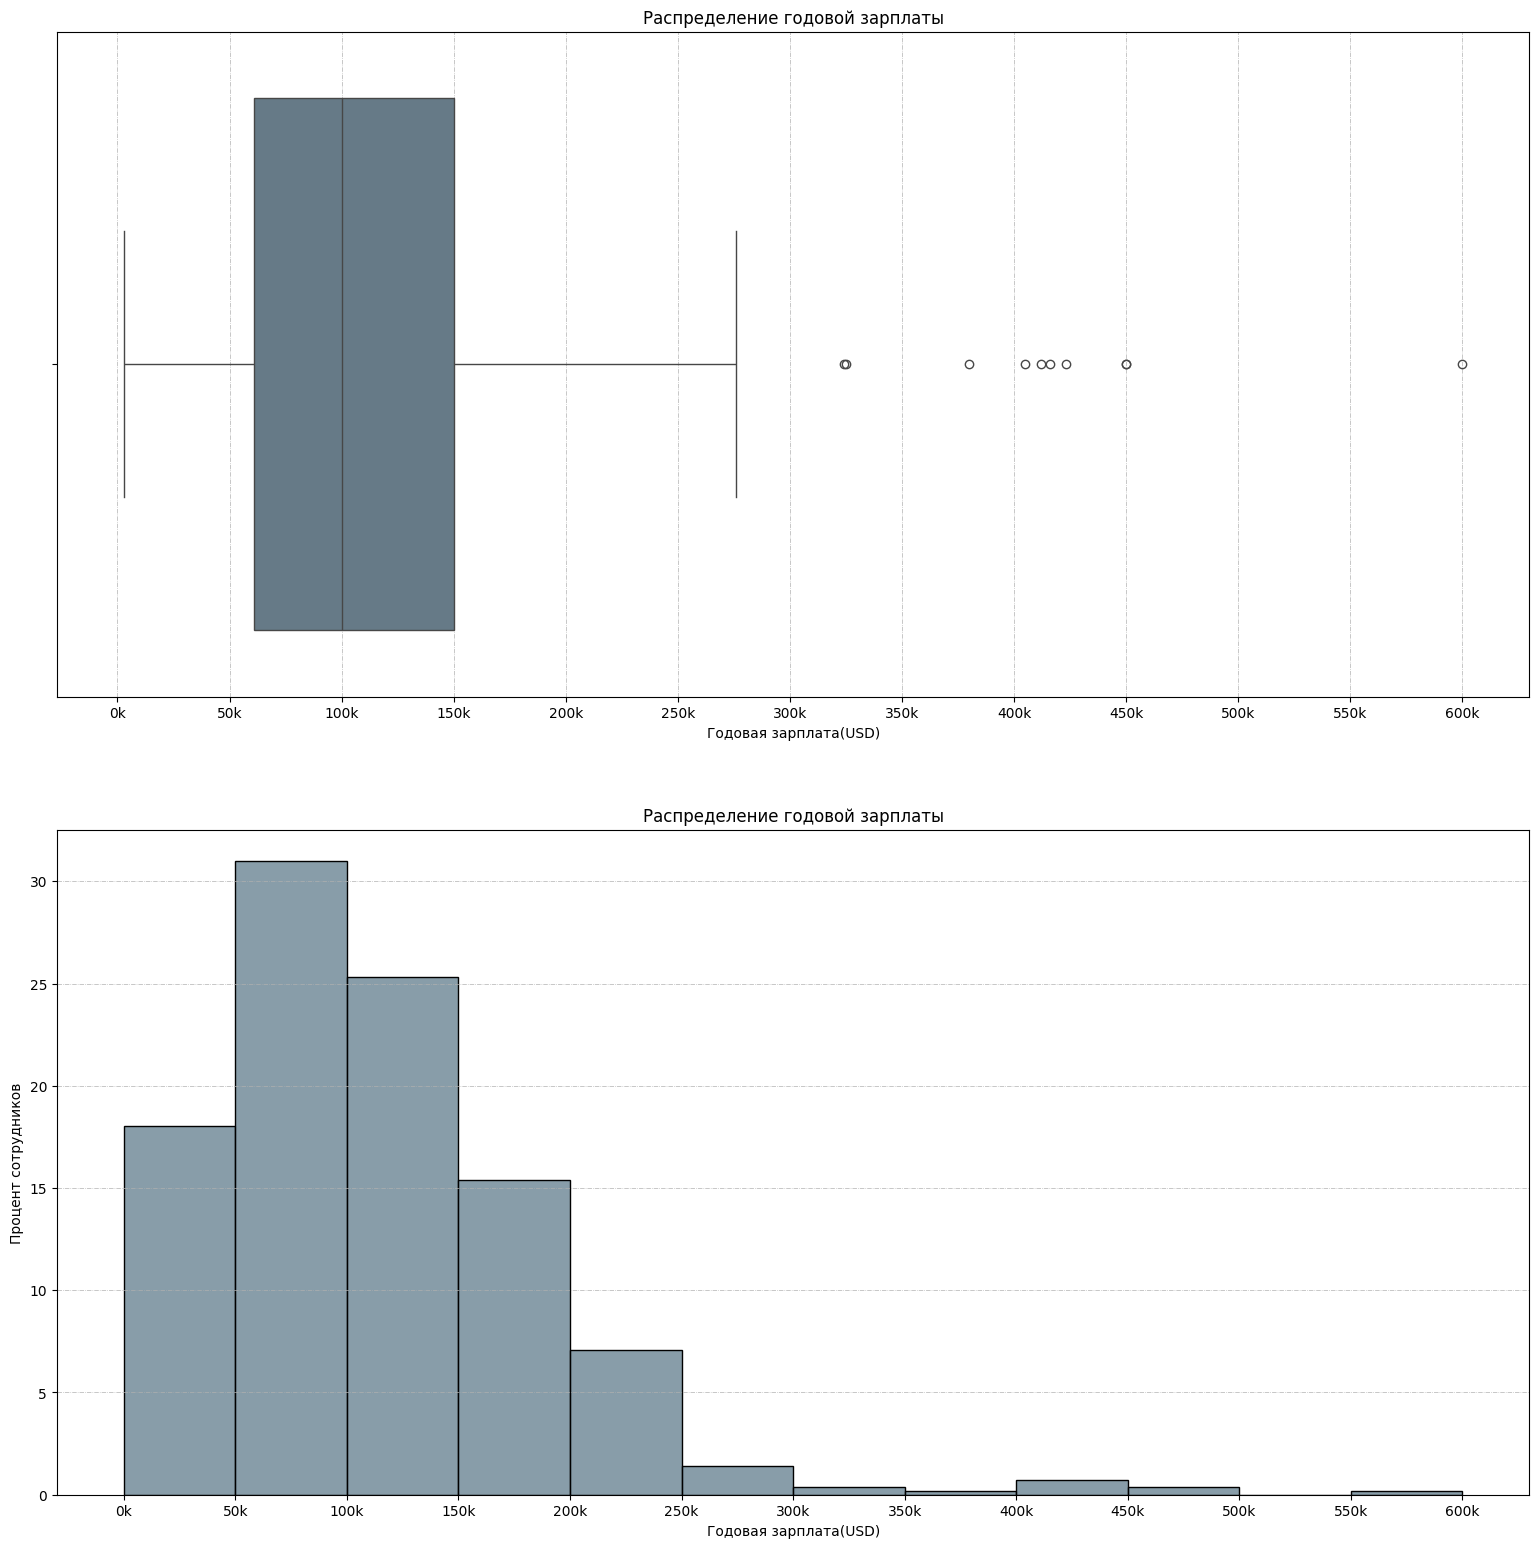

In [140]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19,19))
# boxplot
boxplot = sns.boxplot(
    data=data,
    x='salary_in_usd',
    color='#607C8C',
    ax=axes[0]
)
# set lables name
boxplot.set_title('Распределение годовой зарплаты')
boxplot.set_xlabel('Годовая зарплата(USD)')
# set ticks
x_ticks = range(0, data['salary_in_usd'].max() + 5*10**4, 5*10**4)
boxplot.set_xticks(x_ticks)
boxplot.set_xticklabels([f'{int(val/1000)}k' for val in x_ticks])
# grid
boxplot.grid(axis='x', linestyle='-.', linewidth=0.5)


# histplot
histplot = sns.histplot(
    data=data,
    x='salary_in_usd',
    bins=x_ticks,
    stat='percent',
    color='#607C8C',
    ax=axes[1]
)
# set lables name
histplot.set_title('Распределение годовой зарплаты')
histplot.set_xlabel('Годовая зарплата(USD)')
histplot.set_ylabel('Процент сотрудников')
# set ticks
histplot.set_xticks(x_ticks)
histplot.set_xticklabels([f'{int(val/1000)}k' for val in x_ticks])
# grid
histplot.grid(axis='y', linestyle='-.', linewidth=0.5)

In [141]:
data['salary_in_usd'].describe().round(2).to_frame()

,salary_in_usd
count,565.00
mean,110610.34
std,72280.70
min,2859.00
25%,60757.00
50%,100000.00
75%,150000.00
max,600000.00


Вывод:  
Распределение данных не является нормальным. Основная часть наблюдений находится в диапазоне 50-150 тыс. Диапазон типичных значений 0-250 тыс. В данных присутствуют выбросы.

### 2.1 Распределение медианной годовой зарплаты по годам и профессиональным направлениям

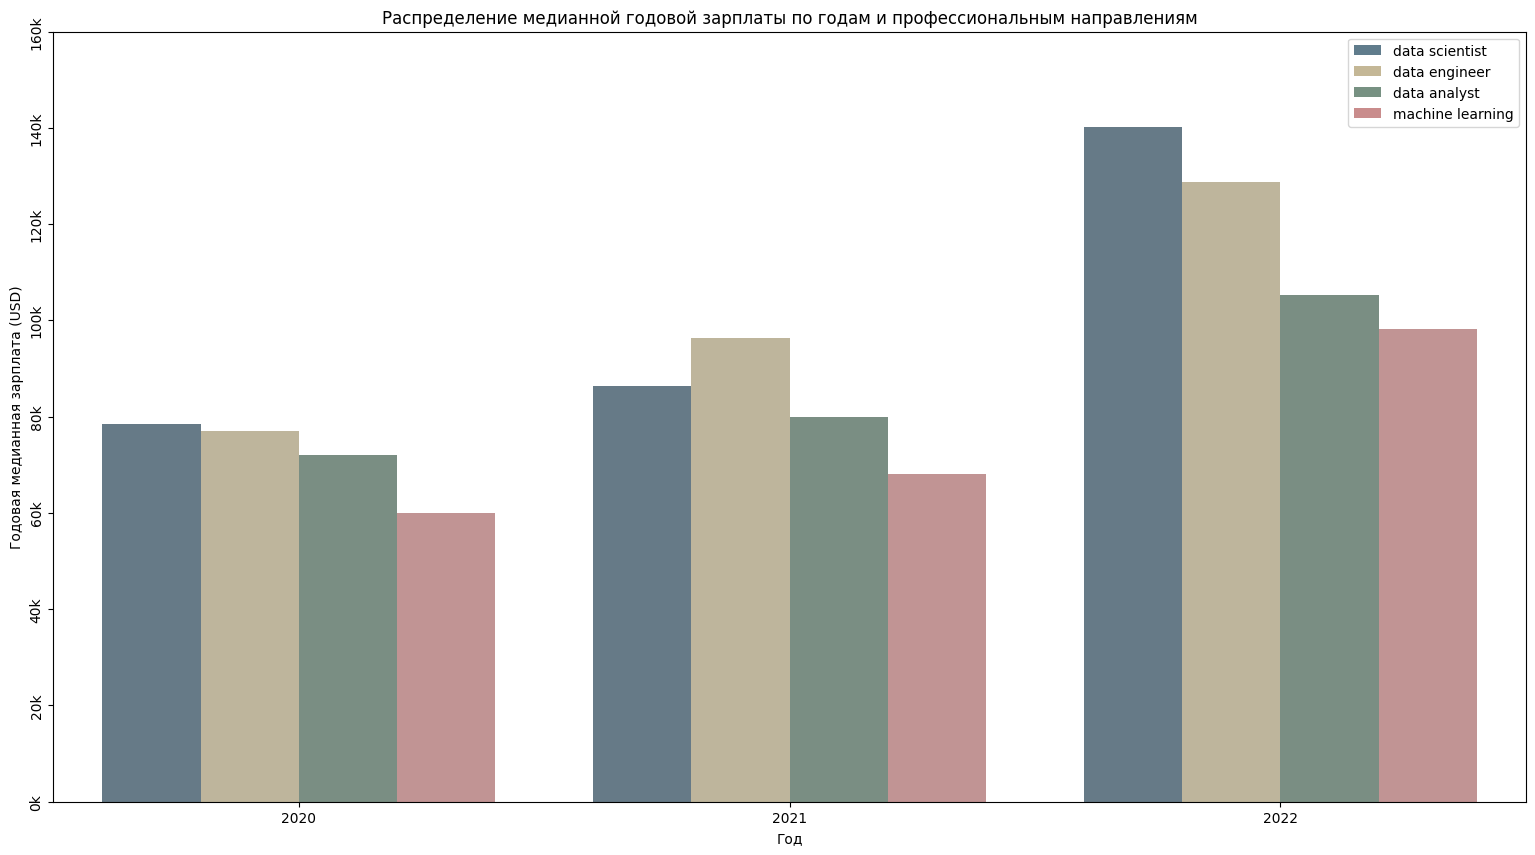

In [142]:
fig = plt.figure(figsize=(19,10))
# barplot
barplot = sns.barplot(
    data=data,
    x='work_year',
    y='salary_in_usd',
    hue='domain',
    hue_order=['data scientist', 'data engineer', 'data analyst', 'machine learning'],
    palette=['#607C8C','#C4B796',  '#779182', '#C98C8C'],
    estimator='median',
    errorbar=None
)
# set labels name
barplot.set_title('Распределение медианной годовой зарплаты по годам и профессиональным направлениям')
barplot.set_xlabel('Год')
barplot.set_ylabel('Годовая медианная зарплата (USD)')
# set ticks
max_sal = int(data.groupby(['work_year', 'domain'])['salary_in_usd'].median().max())
y_ticks = range(0, max_sal + 2*10**4, 2*10**4)
barplot.set_yticks(y_ticks)
barplot.set_yticklabels([f'{int(val/1000)}k' for val in y_ticks], rotation=90, va='center');
# set legend
legend_handles = [Patch(facecolor='#607C8C', label='data scientist'), 
                  Patch(facecolor='#C4B796', label='data engineer'),
                  Patch(facecolor='#779182', label='data analyst'),
                  Patch(facecolor='#C98C8C', label='machine learning'),]
barplot.legend(handles=legend_handles, title=None);

Вывод:
График показывает положительный тренд медианной годовой зарплаты по всем профессиональным направлениям. 

### 2.2 Распределение годовой зарплаты по профессиональному уровню

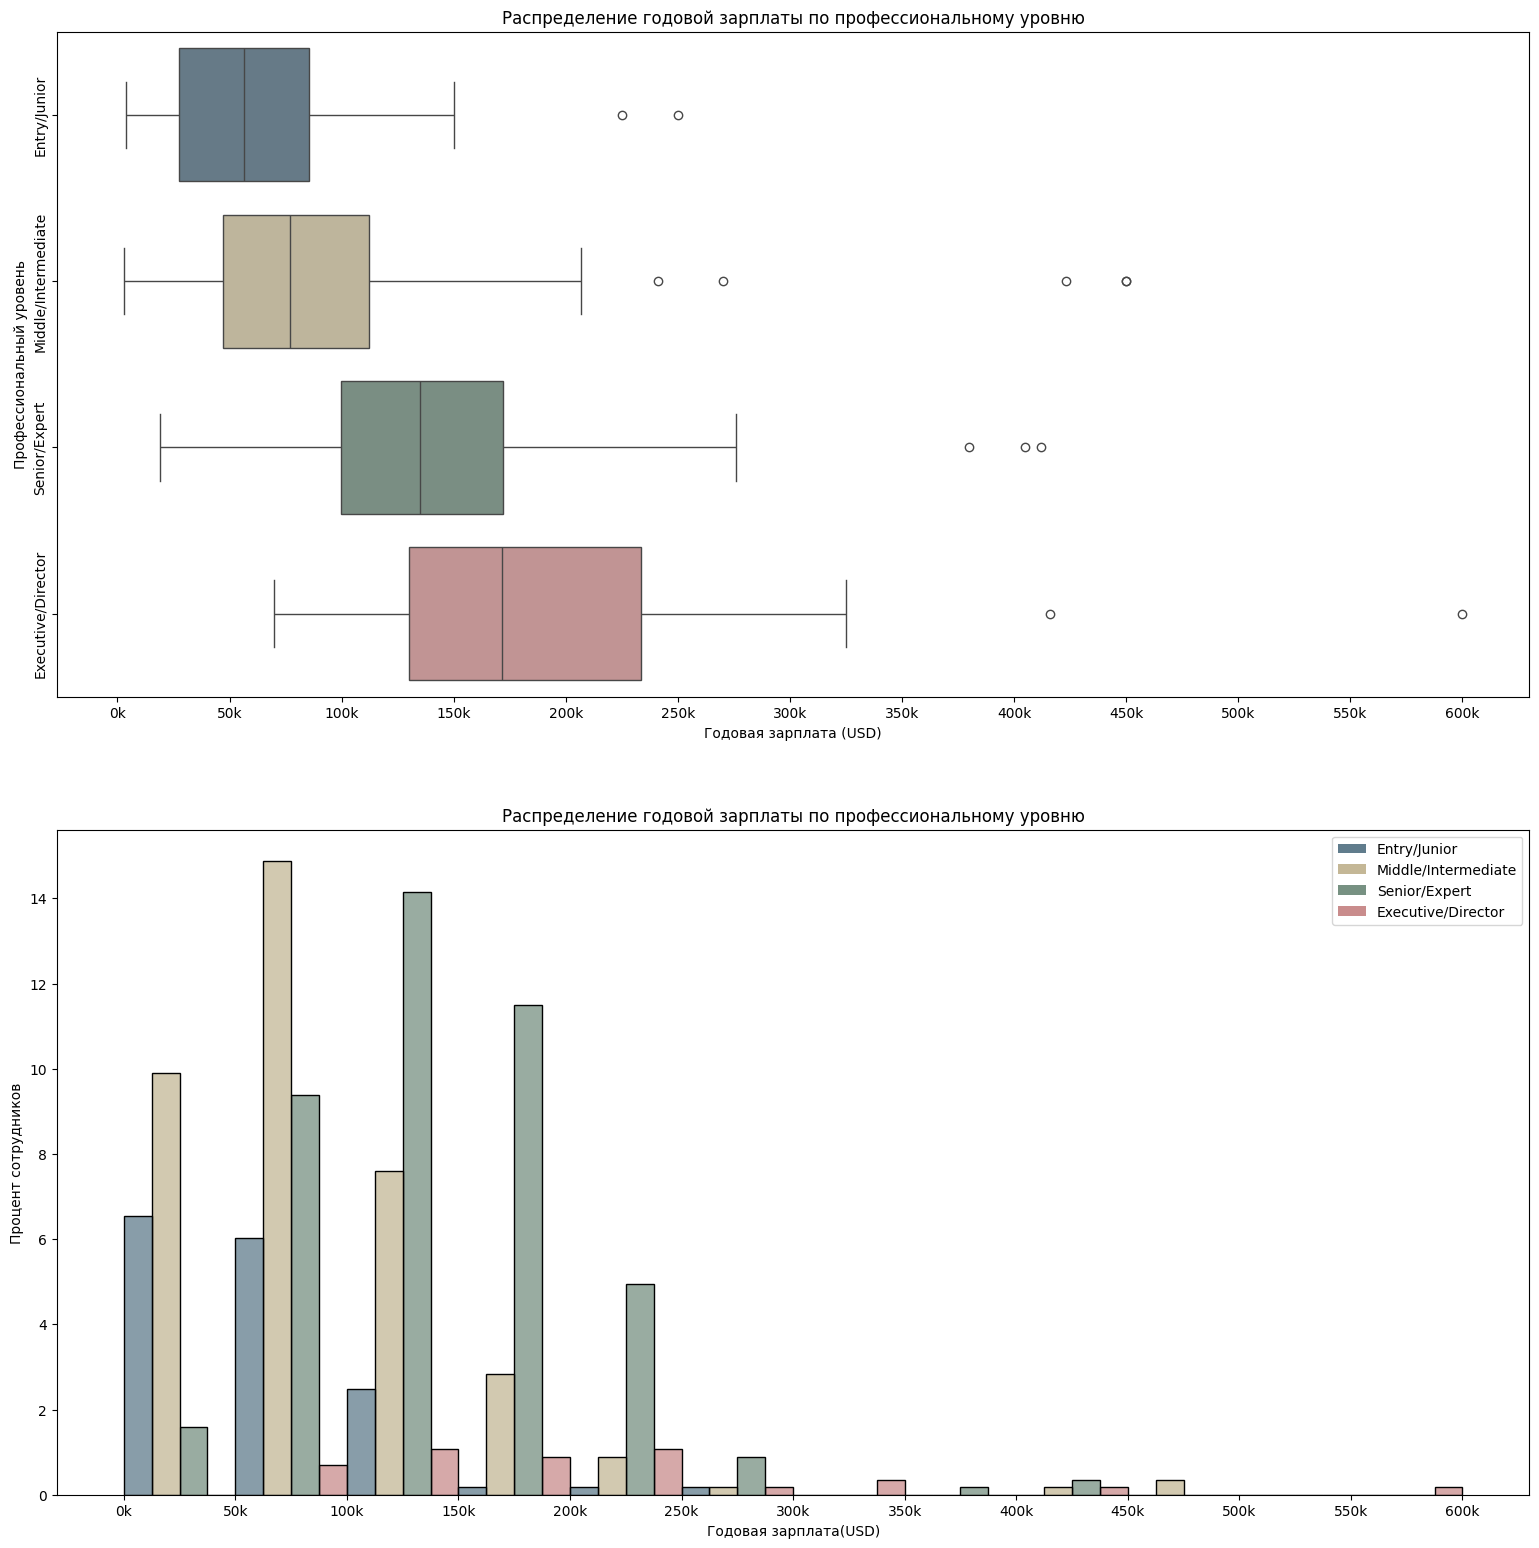

In [143]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19,19))
# boxplot
boxplot = sns.boxplot(
    data=data,
    x='salary_in_usd',
    y='experience_level',
    hue='experience_level',
    order=['EN', 'MI', 'SE', 'EX'],
    hue_order=['EN', 'MI', 'SE', 'EX'],
    palette=['#607C8C','#C4B796',  '#779182', '#C98C8C'],
    ax=axes[0]
)
# set labels name
boxplot.set_title('Распределение годовой зарплаты по профессиональному уровню')
boxplot.set_xlabel('Годовая зарплата (USD)')
boxplot.set_ylabel('Профессиональный уровень')
# set ticks
x_ticks = range(0, data['salary_in_usd'].max() + 5*10**4, 5*10**4)
boxplot.set_xticks(x_ticks)
boxplot.set_xticklabels([f'{int(val/1000)}k' for val in x_ticks])
boxplot.set_yticks(['EN', 'MI', 'SE', 'EX'])
boxplot.set_yticklabels(['Entry/Junior', 'Middle/Intermediate', 'Senior/Expert', 'Executive/Director'], rotation=90, va='center')


# histplot
histplot = sns.histplot(
    data=data,
    x='salary_in_usd',
    hue='experience_level',
    hue_order=['EN', 'MI', 'SE', 'EX'],
    stat='percent',
    bins=x_ticks,
    multiple='dodge',
    palette=['#607C8C','#C4B796',  '#779182', '#C98C8C'],
    ax=axes[1]
)
# set labels name
histplot.set_title('Распределение годовой зарплаты по профессиональному уровню')
histplot.set_xlabel('Годовая зарплата(USD)')
histplot.set_ylabel('Процент сотрудников')
# set ticks
histplot.set_xticks(x_ticks)
histplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
# set legend
legend_handles = [Patch(facecolor='#607C8C', label='Entry/Junior'), 
                  Patch(facecolor='#C4B796', label='Middle/Intermediate'),
                  Patch(facecolor='#779182', label='Senior/Expert'),
                  Patch(facecolor='#C98C8C', label='Executive/Director')]
histplot.legend(handles=legend_handles, title=None);

In [144]:
order = ['EN', 'MI', 'SE', 'EX']
data.groupby('experience_level')['salary_in_usd'].describe().round(2).loc[order]

,count,mean,std,min,25%,50%,75%,max
experience_level,,,,,,,,
EN,88.0,61643.32,44395.54,4000.0,27505.00,56500.0,85425.75,250000.0
MI,208.0,87793.00,64118.97,2859.0,47163.75,76940.0,112075.00,450000.0
SE,243.0,138374.88,59955.97,18907.0,99531.50,135000.0,171881.00,412000.0
EX,26.0,199392.04,117071.26,69741.0,130006.50,171437.5,233750.00,600000.0


Вывод:  
Данные демонстрируют стремительный рост годовых зарплат с повышением профессионального уровня.

### 2.3 Распределение годовой зарплаты по типу занятости

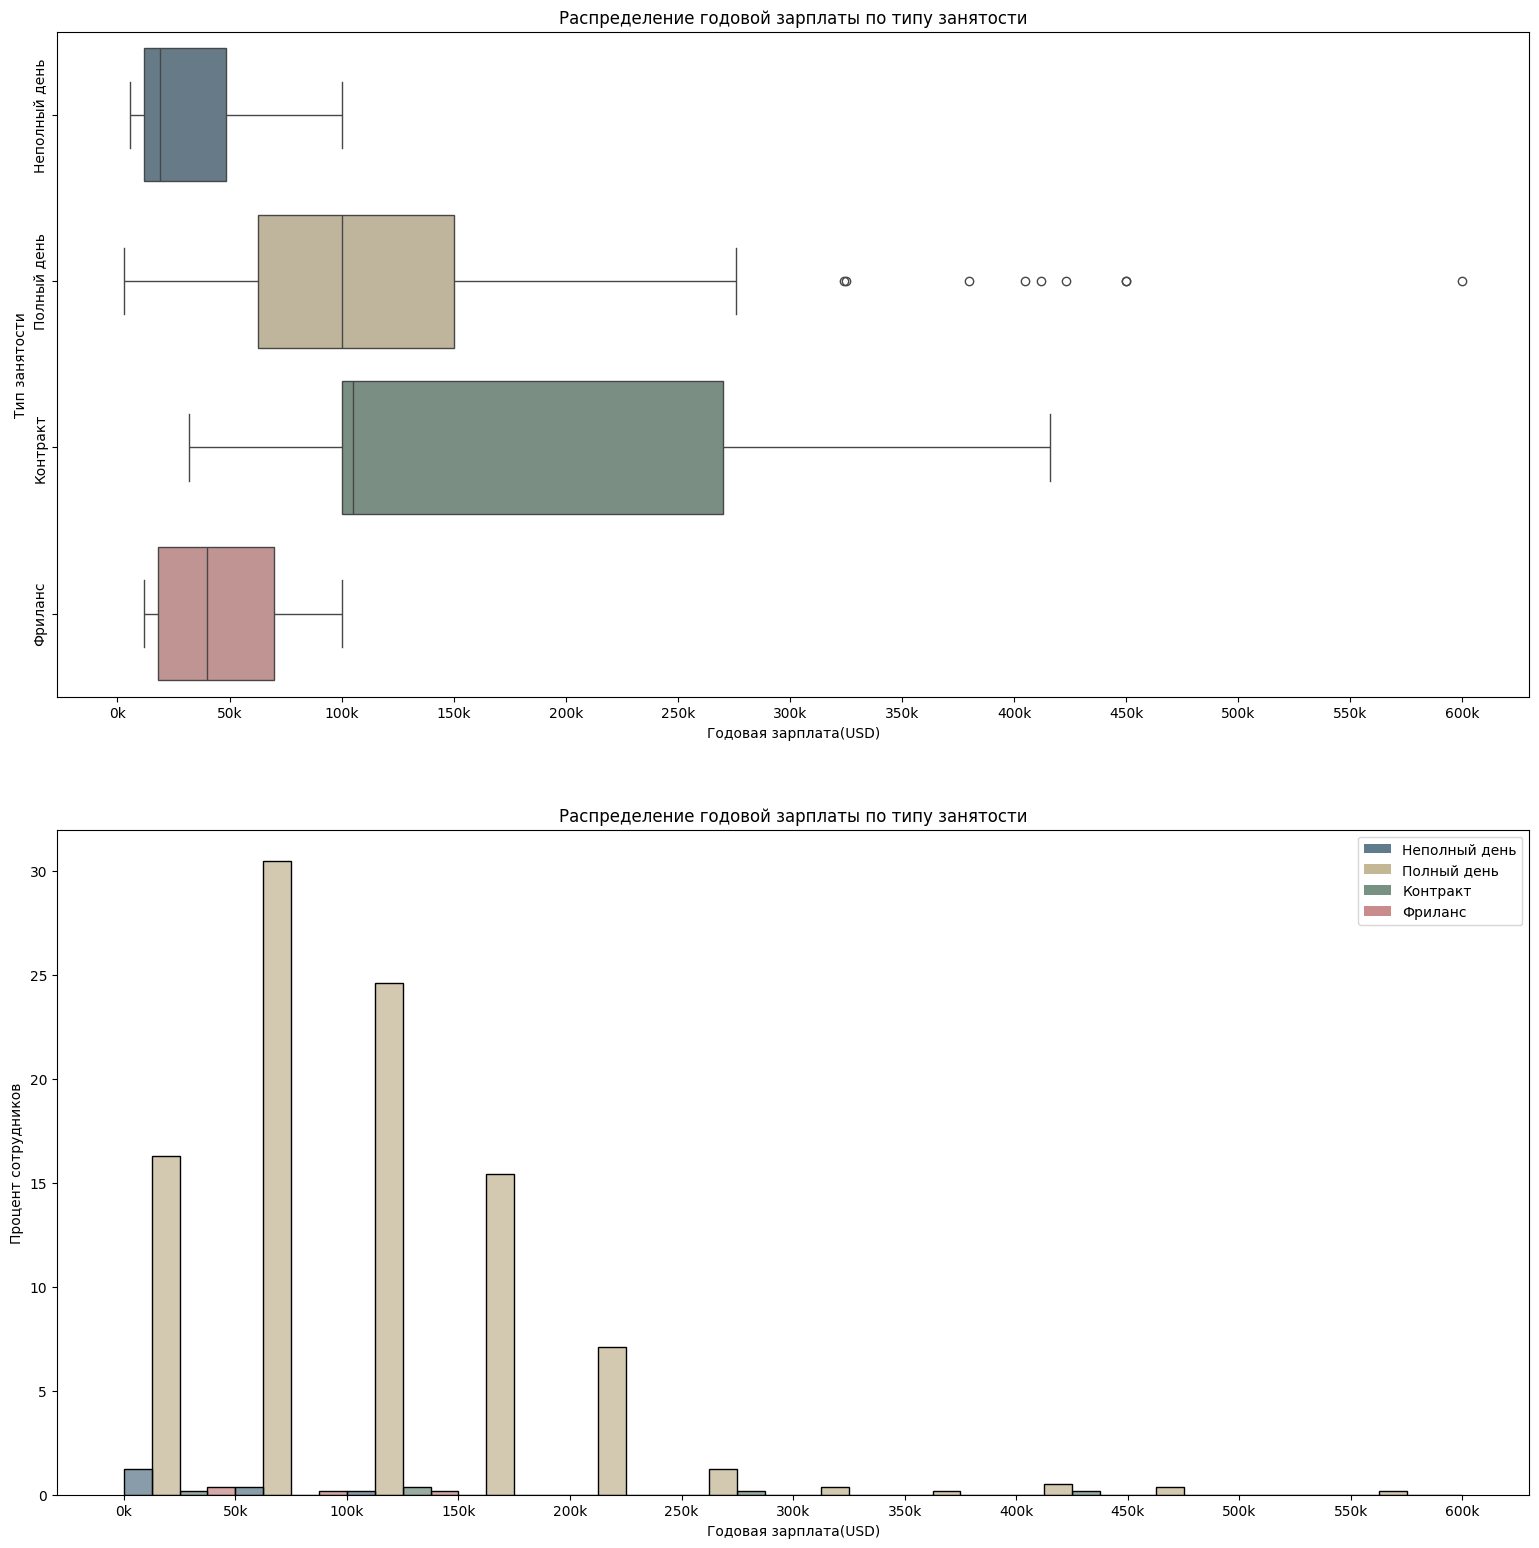

In [145]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19,19))
# boxplot
boxplot = sns.boxplot(
    data=data,
    x='salary_in_usd',
    y='employment_type',
    hue='employment_type',
    order=['PT', 'FT', 'CT', 'FL'],
    hue_order=['PT', 'FT', 'CT', 'FL'],
    palette=['#607C8C','#C4B796',  '#779182', '#C98C8C'],
    ax=axes[0]
)
# set labels name
boxplot.set_title('Распределение годовой зарплаты по типу занятости')
boxplot.set_xlabel('Годовая зарплата(USD)')
boxplot.set_ylabel('Тип занятости')
# set ticks
x_ticks = range(0, data['salary_in_usd'].max() + 5*10**4, 5*10**4)
boxplot.set_xticks(x_ticks)
boxplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
boxplot.set_yticks(['PT', 'FT', 'CT', 'FL'])
boxplot.set_yticklabels(['Неполный день', 'Полный день', 'Контракт', 'Фриланс'], rotation=90, va='center')


# histplot
histplot = sns.histplot(
    data=data,
    x='salary_in_usd',
    hue='employment_type',
    hue_order=['PT', 'FT', 'CT', 'FL'],
    stat='percent',
    bins=x_ticks,
    multiple='dodge',
    palette=['#607C8C','#C4B796',  '#779182', '#C98C8C'],
    ax=axes[1]
)
# set labels name
histplot.set_title('Распределение годовой зарплаты по типу занятости')
histplot.set_xlabel('Годовая зарплата(USD)')
histplot.set_ylabel('Процент сотрудников')
# set ticks
histplot.set_xticks(x_ticks)
histplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
# set legend
legend_handles = [Patch(facecolor='#607C8C', label='Неполный день'), 
                  Patch(facecolor='#C4B796', label='Полный день'),
                  Patch(facecolor='#779182', label='Контракт'),
                  Patch(facecolor='#C98C8C', label='Фриланс'),]
histplot.legend(handles=legend_handles, title=None);

In [146]:
order = ['PT', 'FT', 'CT', 'FL']
data.groupby('employment_type')['salary_in_usd'].describe().round(2).loc[order]

,count,mean,std,min,25%,50%,75%,max
employment_type,,,,,,,,
PT,10.0,33070.50,31472.91,5409.0,12000.0,18817.5,48370.0,100000.0
FT,546.0,111811.84,70790.70,2859.0,62726.0,100000.0,150000.0,600000.0
CT,5.0,184575.00,156250.89,31875.0,100000.0,105000.0,270000.0,416000.0
FL,4.0,48000.00,40529.82,12000.0,18000.0,40000.0,70000.0,100000.0


Вывод:  
В данной выборке наблюдается значительный дисбаланс между категориями; проведение статистических тестов для сравнения этих групп нецелесообразно.

### 2.4 Распределение годовой зарплаты по объему удаленной работы

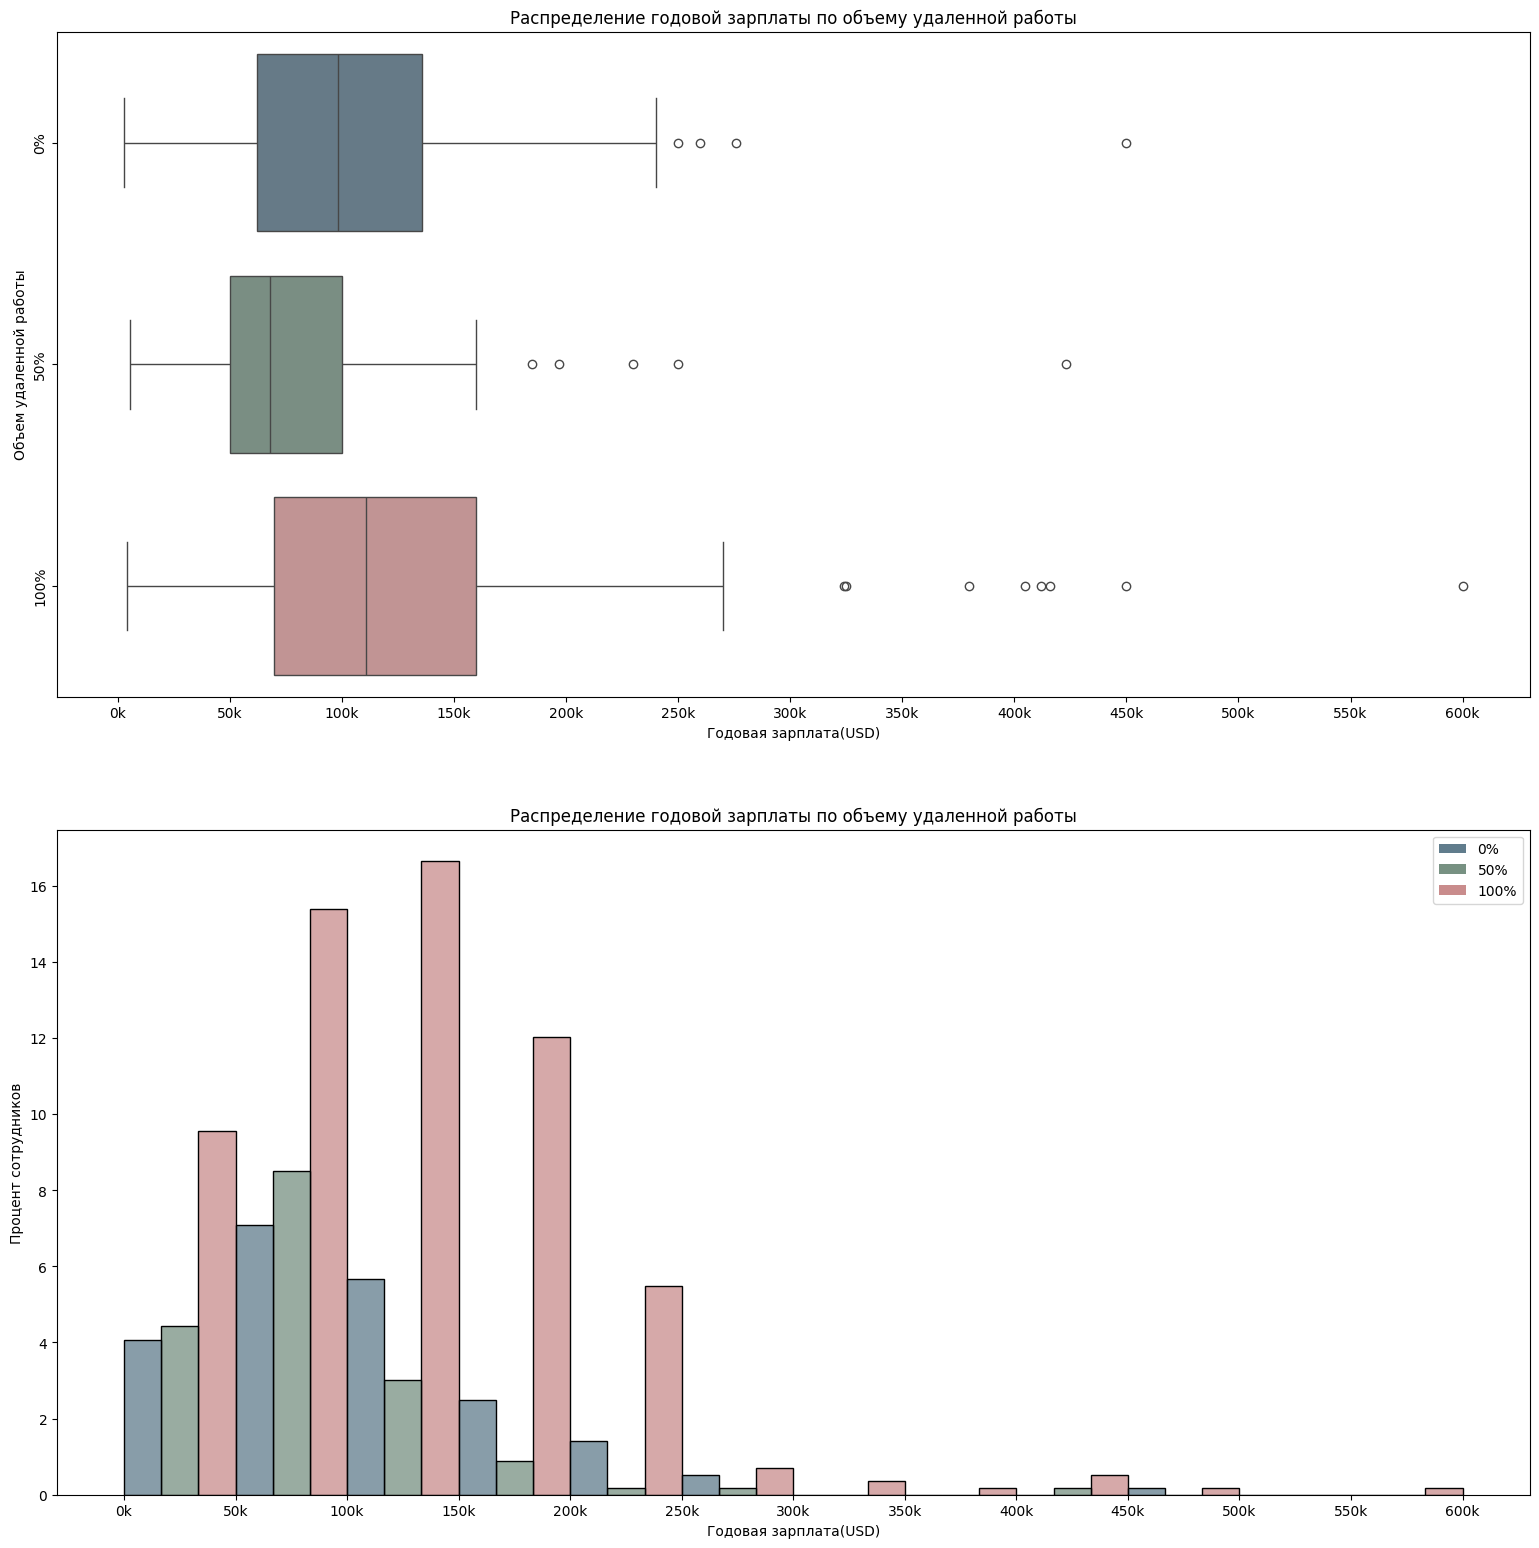

In [147]:
data['remote_ratio'] = data['remote_ratio'].astype(str)
# figure
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19,19))
# boxplot
boxplot = sns.boxplot(
    data=data,
    x='salary_in_usd',
    y='remote_ratio',
    hue='remote_ratio',
    order=['0', '50', '100'],
    hue_order=['0', '50', '100'],
    palette=['#607C8C', '#779182', '#C98C8C'],
    ax=axes[0]
)
# set labels name
boxplot.set_title('Распределение годовой зарплаты по объему удаленной работы')
boxplot.set_xlabel('Годовая зарплата(USD)')
boxplot.set_ylabel('Объем удаленной работы')
# set ticks
x_ticks = range(0, data['salary_in_usd'].max() + 5*10**4, 5*10**4)
boxplot.set_xticks(x_ticks)
boxplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
boxplot.set_yticks(['0', '50', '100'])
boxplot.set_yticklabels(['0%', '50%', '100%'], rotation=90, va='center')


# histplot
histplot = sns.histplot(
    data=data,
    x='salary_in_usd',
    hue='remote_ratio',
    stat='percent',
    bins=x_ticks,
    multiple='dodge',
    palette=['#607C8C', '#779182', '#C98C8C'],
    ax=axes[1]
) 
# set labels name
histplot.set_title('Распределение годовой зарплаты по объему удаленной работы')
histplot.set_xlabel('Годовая зарплата(USD)')
histplot.set_ylabel('Процент сотрудников')
# set ticks
histplot.set_xticks(x_ticks)
histplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
# set legend
legend_handles = [Patch(facecolor='#607C8C', label='0%'), 
                  Patch(facecolor='#779182', label='50%'),
                  Patch(facecolor='#C98C8C', label='100%')]
histplot.legend(handles=legend_handles, title=None);

In [148]:
order = ['0', '50', '100']
data.groupby(['remote_ratio', 'experience_level'])['salary_in_usd'].describe().round(2).loc[order]

count       mean        std      min       25%  \
remote_ratio experience_level                                                   
0            EN                 14.0   57666.36   40587.67   4000.0   24979.0   
             EX                  3.0  158948.67   83819.01  85000.0  113423.0   
             MI                 54.0   83079.74   66574.01   2859.0   45807.0   
             SE                 50.0  140591.06   57433.10  18907.0  100425.5   
50           EN                 25.0   60099.28   48631.77   5707.0   28609.0   
             EX                  5.0  143175.40   68432.42  79039.0   79833.0   
             MI                 41.0   76112.51   65228.29   5409.0   51064.0   
             SE                 27.0   95250.89   39160.57  20171.0   62863.5   
100          EN                 49.0   63567.37   43977.89   9272.0   28399.0   
             EX                 18.0  221748.33  128373.01  69741.0  138750.0   
             MI                113.0   94283.40   62276.97   4000.0   48000.0   
             SE                166.0  144721.50   60866.30  24000.0  104917.5   

                                    50%        75%       max  
remote_ratio experience_level                                 
0            EN                 51660.5   94208.25  125000.0  
             EX                141846.0  195923.00  250000.0  
             MI                 75000.0  105220.00  450000.0  
             SE                135500.0  180000.00  276000.0  
50           EN                 55000.0   81000.00  250000.0  
             EX                130026.0  196979.00  230000.0  
             MI                 62726.0   88654.00  423000.0  
             SE                 94665.0  120000.00  185000.0  
100          EN                 59102.0   90000.00  225000.0  
             EX                187500.0  240250.00  600000.0  
             MI                 87000.0  120000.00  450000.0  
             SE                144000.0  175075.00  412000.0

Вывод:  
Данный график демонстрирует большинство специалистов в выборке работают удалённо. Специалисты, работающие и удалённо, и в офисе, получают зарплату ниже, чем те, кто работает только в офисе или только удалённо. Полностью удалённые специалисты составляют наибольшую долю и получают наибольшую зарплату. Выбросы присутствуют в каждой категории.

### 2.5 Распределение годовй зарплаты по совпадению страны сотрудника и компании

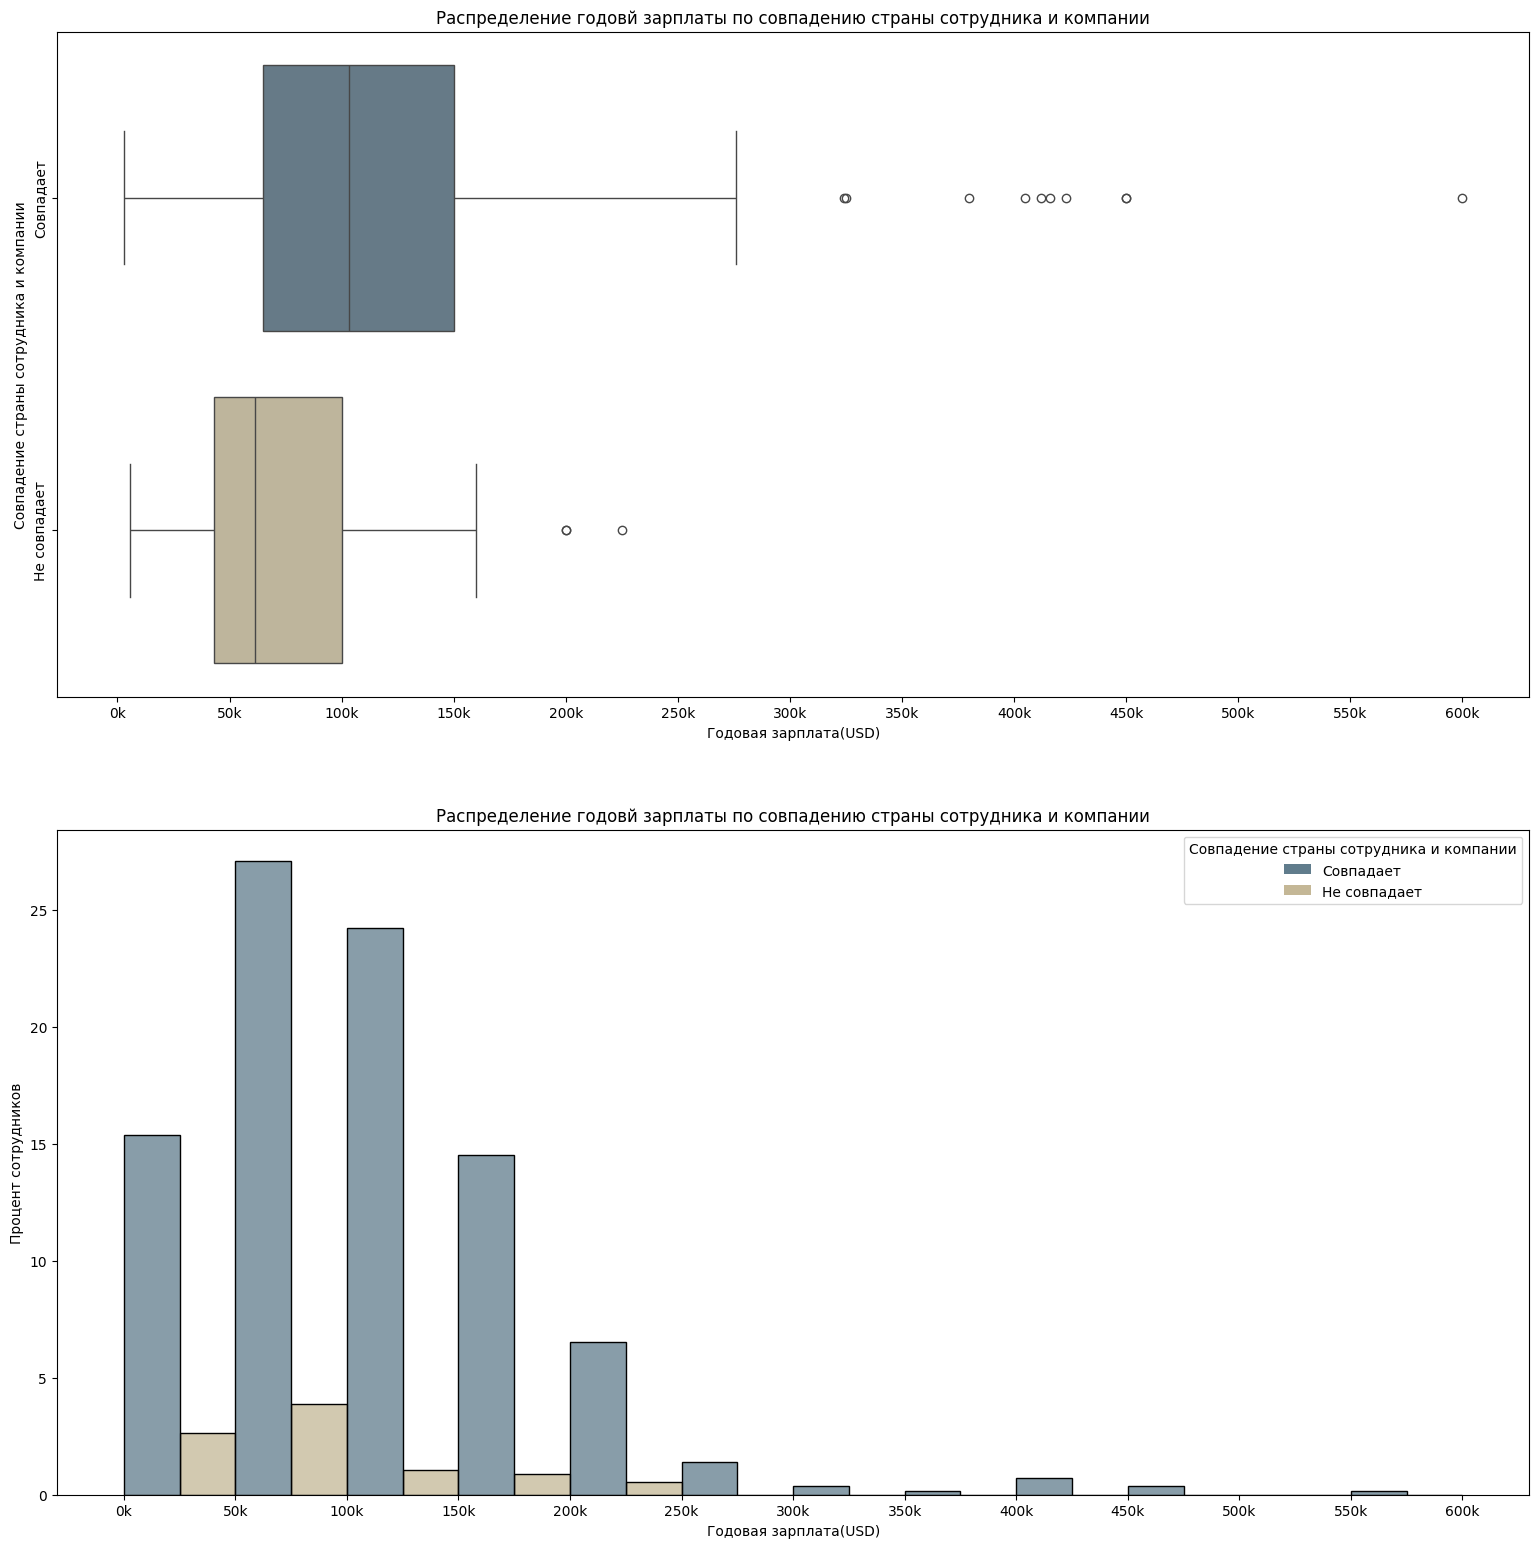

In [149]:
data['is_same_country'] = data['is_same_country'].astype(str)
# figure
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19,19))
# boxplot
boxplot = sns.boxplot(
    data=data,
    x='salary_in_usd',
    y='is_same_country',
    hue='is_same_country',
    palette=['#607C8C','#C4B796'],
    ax=axes[0]
)
# set labels name
boxplot.set_title('Распределение годовй зарплаты по совпадению страны сотрудника и компании')
boxplot.set_xlabel('Годовая зарплата(USD)')
boxplot.set_ylabel('Совпадение страны сотрудника и компании')
# set ticks
x_ticks = range(0, data['salary_in_usd'].max() + 5*10**4, 5*10**4)
boxplot.set_xticks(x_ticks)
boxplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
boxplot.set_yticks(['True', 'False'])
boxplot.set_yticklabels(['Совпадает', 'Не совпадает'], rotation=90, va='center')


# histplot
histplot = sns.histplot(
    data=data,
    x='salary_in_usd',
    hue='is_same_country',
    stat='percent',
    bins=x_ticks,
    multiple='dodge',
    palette=['#607C8C','#C4B796'],
    ax=axes[1]
)
# set labels name
histplot.set_title('Распределение годовй зарплаты по совпадению страны сотрудника и компании')
histplot.set_xlabel('Годовая зарплата(USD)')
histplot.set_ylabel('Процент сотрудников')
# set ticks
histplot.set_xticks(x_ticks)
histplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
# set legend
legend_handles = [Patch(facecolor='#607C8C', label='Совпадает'), 
                  Patch(facecolor='#C4B796', label='Не совпадает')]
histplot.legend(handles=legend_handles, title='Совпадение страны сотрудника и компании');

In [150]:
order = ['True', 'False']
data.groupby(['is_same_country', 'experience_level'])['salary_in_usd'].describe().round(2).loc[order]

count       mean        std      min  \
is_same_country experience_level                                         
True            EN                 77.0   64896.43   45105.38   4000.0   
                EX                 23.0  209164.57  120435.89  79039.0   
                MI                187.0   90087.26   65667.23   2859.0   
                SE                227.0  140643.35   59670.86  18907.0   
False           EN                 11.0   38871.55   32145.46   5882.0   
                EX                  3.0  124469.33   47431.58  69741.0   
                MI                 21.0   67363.10   44278.41   5679.0   
                SE                 16.0  106191.00   56262.87  50000.0   

                                       25%       50%       75%       max  
is_same_country experience_level                                          
True            EN                 29751.0   59102.0   90000.0  250000.0  
                EX                130013.0  196979.0  238500.0  600000.0  
                MI                 49461.0   78526.0  113936.0  450000.0  
                SE                101835.0  136620.0  174000.0  412000.0  
False           EN                 12000.0   31875.0   56388.5  100000.0  
                EX                109870.5  150000.0  151833.5  153667.0  
                MI                 38400.0   60000.0   87932.0  200000.0  
                SE                 60000.0   84327.0  154000.0  225000.0

Вывод:  
Данные показывают, что совпадение страны проживания сотрудника и страны компании влияет на годовую зарплату. Сотрудники, работающие в той же стране, где живут, получают больше. Распределение данных отличается от нормального. Выбросы есть в обеих категориях.

### 2.6 Распределение годовой зарплаты по размеру компании

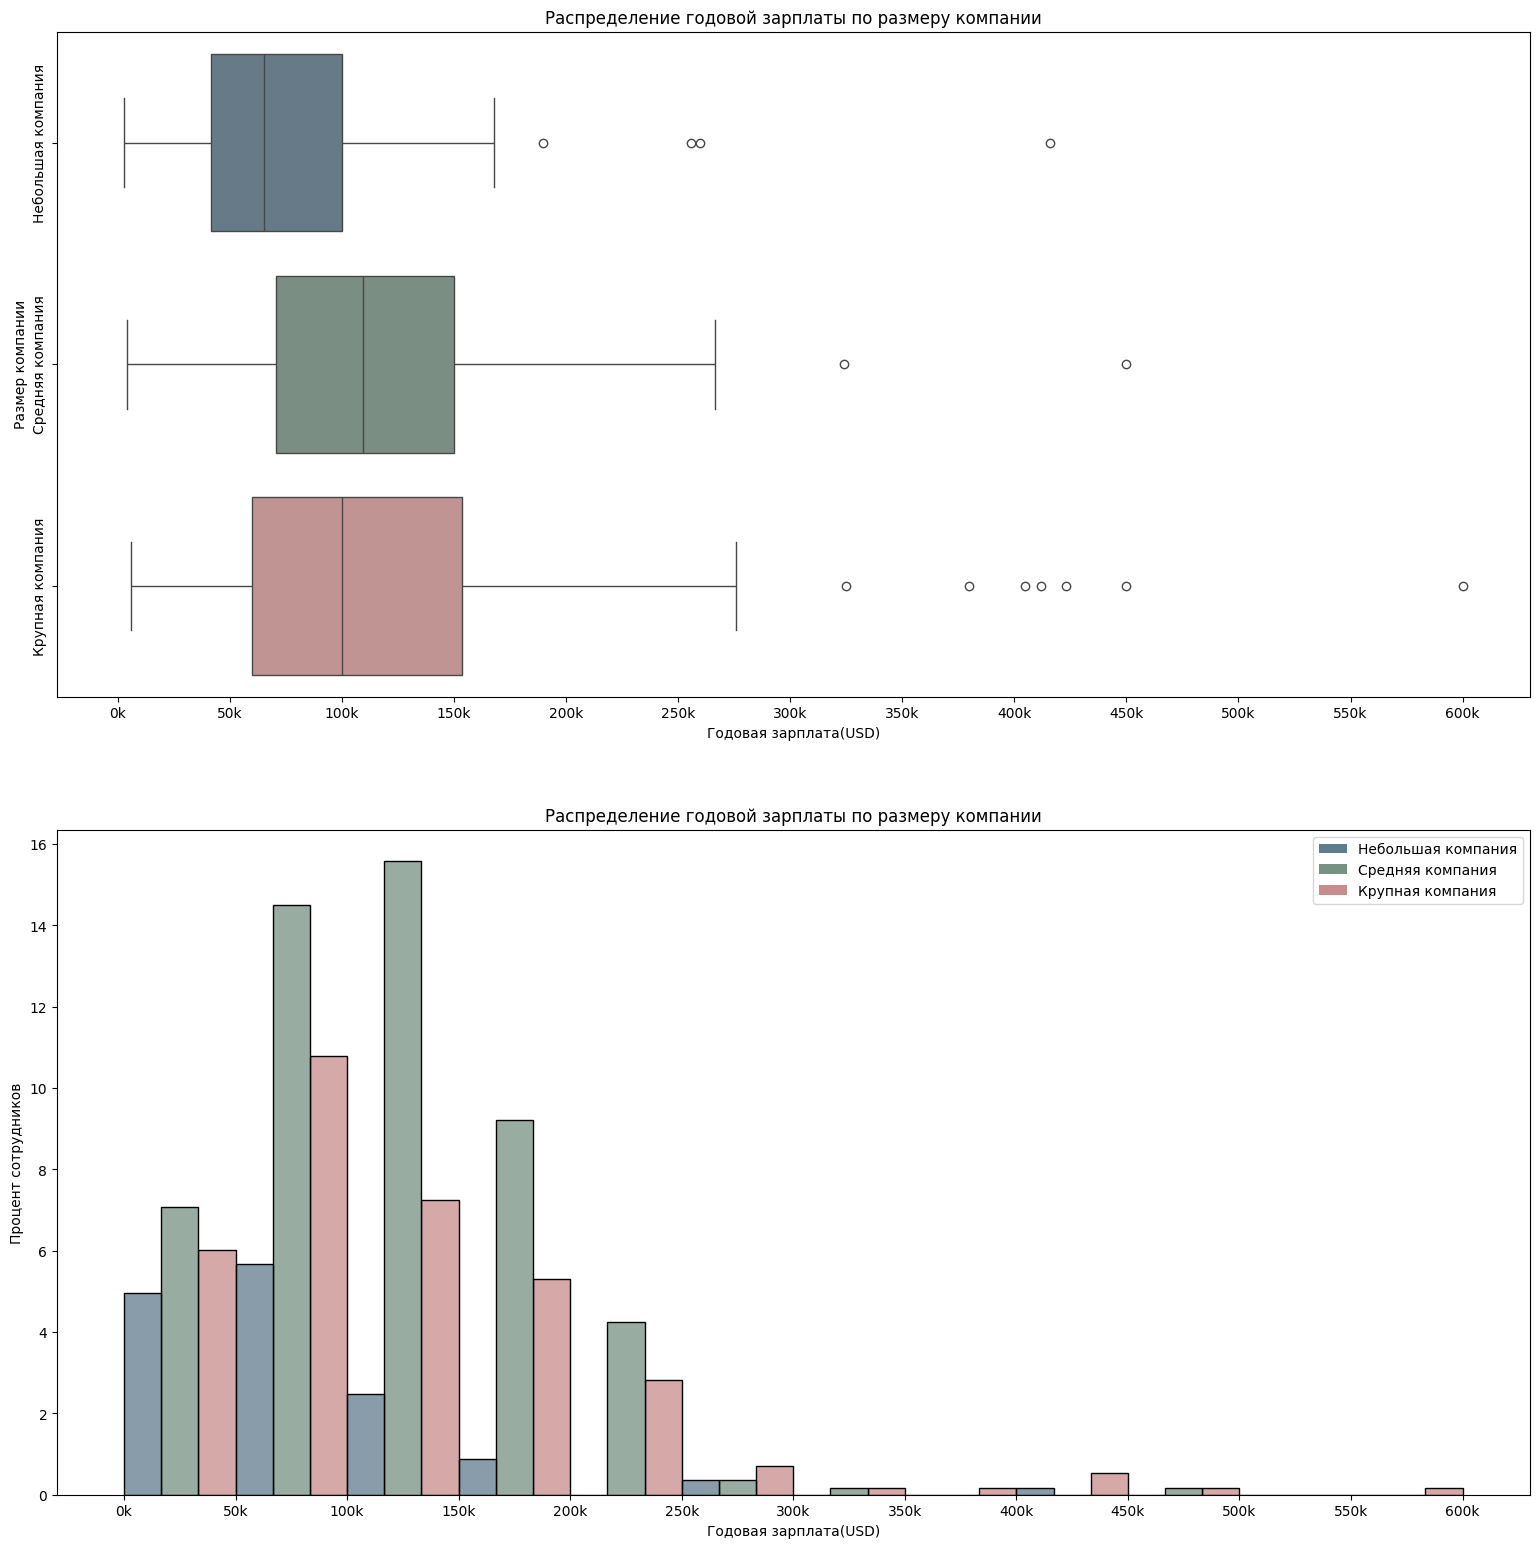

In [151]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19,19))
# boxplot
boxplot = sns.boxplot(
    data=data,
    x='salary_in_usd',
    y='company_size',
    hue='company_size',
    order=['S', 'M', 'L'],
    hue_order=['S', 'M', 'L'],
    palette=['#607C8C', '#779182', '#C98C8C'],
    ax=axes[0]
)
# set labels name
boxplot.set_title('Распределение годовой зарплаты по размеру компании')
boxplot.set_xlabel('Годовая зарплата(USD)')
boxplot.set_ylabel('Размер компании')
# set ticks
x_ticks = range(0, data['salary_in_usd'].max() + 5*10**4, 5*10**4)
boxplot.set_xticks(x_ticks)
boxplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
boxplot.set_yticks(['S', 'M', 'L'])
boxplot.set_yticklabels(['Небольшая компания', 'Средняя компания', 'Крупная компания'], rotation=90, va='center')


# histplot 
histplot = sns.histplot(
    data=data,
    x='salary_in_usd',
    hue='company_size',
    hue_order=['S', 'M', 'L'],
    stat='percent',
    bins=x_ticks,
    multiple='dodge',
    palette=['#607C8C', '#779182', '#C98C8C'],
    ax=axes[1]
)
# set labels name
histplot.set_title('Распределение годовой зарплаты по размеру компании')
histplot.set_xlabel('Годовая зарплата(USD)')
histplot.set_ylabel('Процент сотрудников')
# set ticks
histplot.set_xticks(x_ticks)
histplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
# set legend
legend_handles = [Patch(facecolor='#607C8C', label='Небольшая компания'), 
                  Patch(facecolor='#779182', label='Средняя компания'),
                  Patch(facecolor='#C98C8C', label='Крупная компания')]
histplot.legend(handles=legend_handles, title=None);

In [152]:
order = ['S', 'M', 'L']
data.groupby('company_size')['salary_in_usd'].describe().round(2).loc[order]

,count,mean,std,min,25%,50%,75%,max
company_size,,,,,,,,
S,82.0,77872.10,63814.52,2859.0,41816.0,65511.0,100000.00,416000.0
M,290.0,114807.08,60779.04,4000.0,70821.5,109640.0,150213.75,450000.0
L,193.0,118213.88,86753.27,5882.0,60000.0,100000.0,153667.00,600000.0


Вывод:  
Большая часть сотрудников работает в средних компаниях. Зарплаты в крупных и средних компаниях примерно равны, а в небольших компаниях заметно ниже. Возможно, это связано с тем, что небольшие компании охотнее нанимают сотрудников с небольшим опытом.

### 2.7.1 Распределение опыта сотрудников по размеру компании  
### 2.7.2 Распределение медианной годовой зарплаты по размеру компании и профессиональному опыту сотрудников

#### 

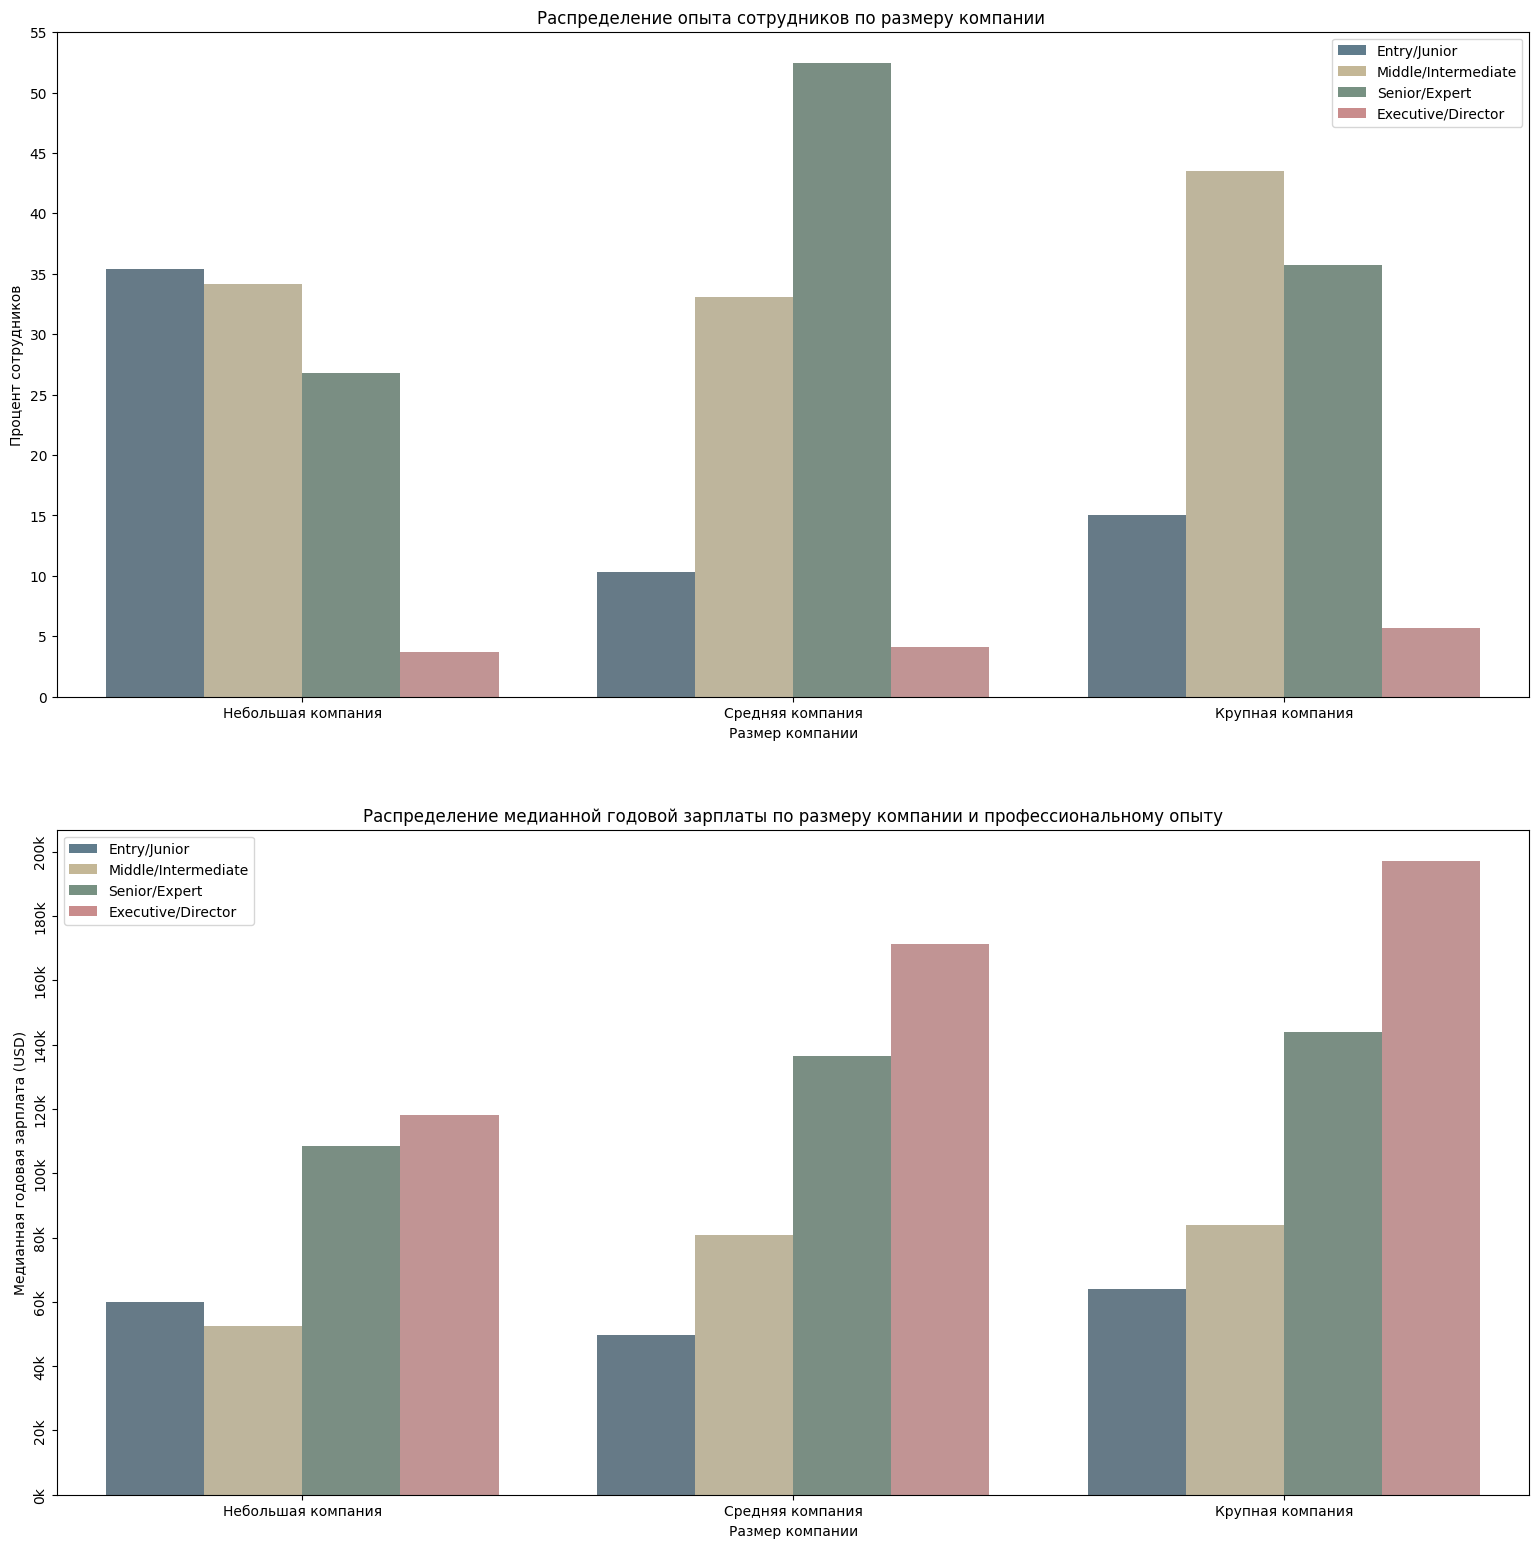

In [153]:
share_levels = data.groupby('company_size', sort=False, as_index=False)['experience_level'].value_counts(normalize=True)
share_levels['proportion'] = round(share_levels['proportion']*100, 2)
median_by_level = data.groupby(['company_size', 'experience_level'], sort=False, as_index=False)['salary_in_usd'].median()
# figure
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19,19))
# barplot
barplot = sns.barplot(
    data=share_levels,
    x='company_size',
    y='proportion',
    hue='experience_level',
    order=['S', 'M', 'L'],
    hue_order=['EN', 'MI', 'SE', 'EX'],
    palette=['#607C8C','#C4B796',  '#779182', '#C98C8C'],
    errorbar=None,
    ax=axes[0]
)
# set labels name
barplot.set_title('Распределение опыта сотрудников по размеру компании ')
barplot.set_xlabel('Размер компании')
barplot.set_ylabel('Процент сотрудников')
# set ticks
barplot.set_xticks(['S', 'M', 'L'])
barplot.set_xticklabels(['Небольшая компания', 'Средняя компания', 'Крупная компания'])
y_ticks = range(0, int(share_levels['proportion'].max()) + 5, 5)
barplot.set_yticks(y_ticks)
# set legend
legend_handles = [Patch(facecolor='#607C8C', label='Entry/Junior'), 
                  Patch(facecolor='#C4B796', label='Middle/Intermediate'),
                  Patch(facecolor='#779182', label='Senior/Expert'),
                  Patch(facecolor='#C98C8C', label='Executive/Director')]
barplot.legend(handles=legend_handles, title=None)


# barplot_0
barplot_0 = sns.barplot(
    data=median_by_level,
    x='company_size',
    y='salary_in_usd',
    hue='experience_level',
    order=['S', 'M', 'L'],
    hue_order=['EN', 'MI', 'SE', 'EX'],
    palette=['#607C8C','#C4B796',  '#779182', '#C98C8C'],
    errorbar=None,
    ax=axes[1]
)
# set labels name
barplot_0.set_title('Распределение медианной годовой зарплаты по размеру компании и профессиональному опыту')
barplot_0.set_xlabel('Размер компании')
barplot_0.set_ylabel('Медианная годовая зарплата (USD)')
# set ticks
barplot_0.set_xticks(['S', 'M', 'L'])
barplot_0.set_xticklabels(['Небольшая компания', 'Средняя компания', 'Крупная компания'])
y_ticks_0 = range(0, int(median_by_level['salary_in_usd'].max()) + 2*10**4, 2*10**4)
barplot_0.set_yticks(y_ticks_0)
barplot_0.set_yticklabels([f'{int(val/1000)}k' for val in y_ticks_0], rotation=90, va='center')
# set legend
legend_handles = [Patch(facecolor='#607C8C', label='Entry/Junior'), 
                  Patch(facecolor='#C4B796', label='Middle/Intermediate'),
                  Patch(facecolor='#779182', label='Senior/Expert'),
                  Patch(facecolor='#C98C8C', label='Executive/Director')]
barplot_0.legend(handles=legend_handles, title=None);

Вывод:  
Данные подтвердили гипотезу: небольшие компании охотнее нанимают сотрудников с небольшим опытом. Также выяснилось, что такие компании платят начинающим специалистам немного больше, чем сотрудникам среднего уровня внутри компании. Медианные зарплаты начинающих специалистов сопоставимы во всех компаниях, в отличии от зарплат остальных специалистов.

### 2.7.3 Распределение годовой зарплаты по размеру компании для профессионального направления data scientist

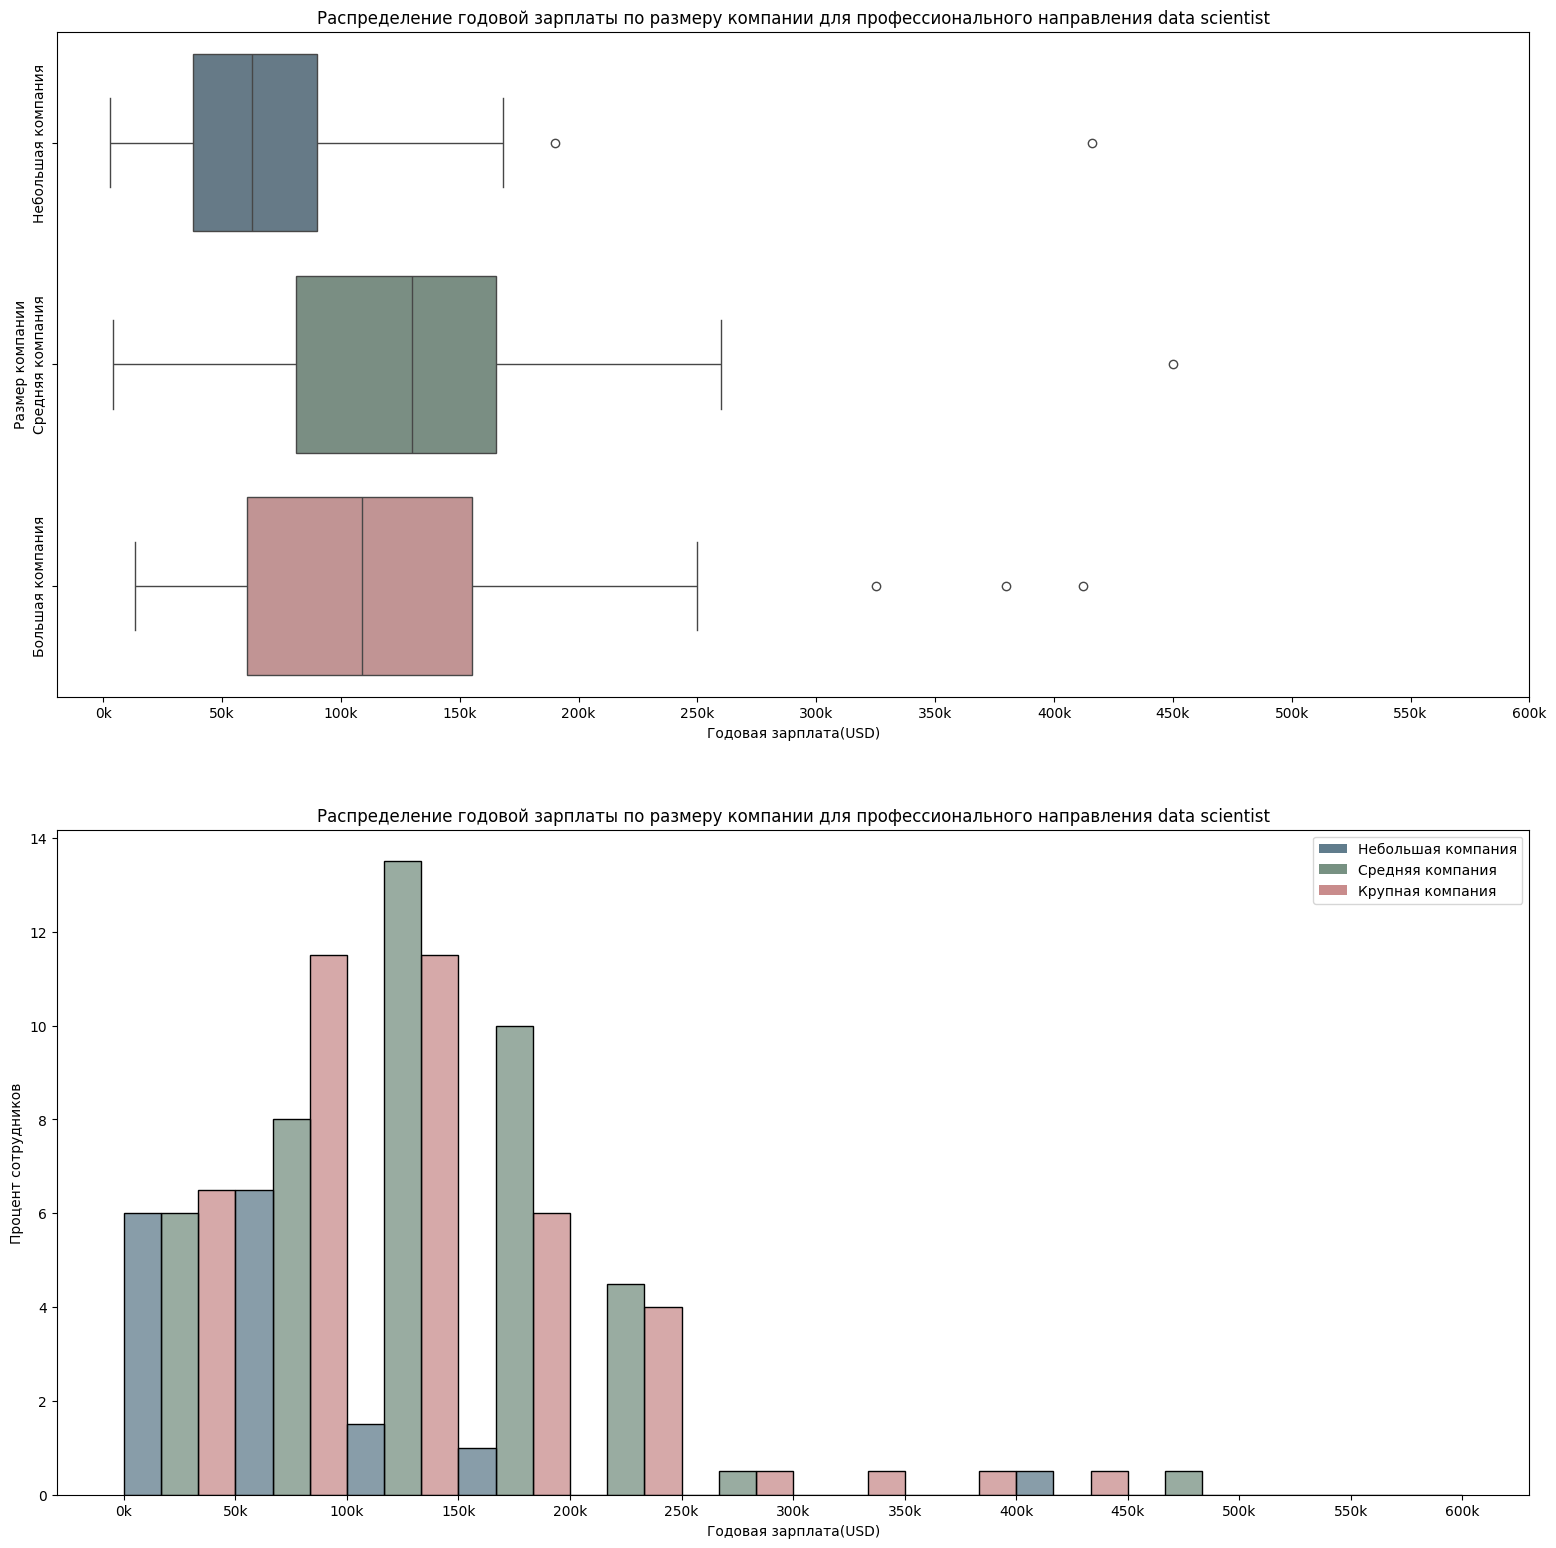

In [154]:
ds_only = data[data['domain'] == 'data scientist']
# figuere
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19,19))
# boxplot
boxplot = sns.boxplot(
    data=ds_only,
    x='salary_in_usd',
    y='company_size',
    hue='company_size',
    order=['S', 'M', 'L'],
    hue_order=['S', 'M', 'L'],
    palette=['#607C8C','#779182', '#C98C8C'],
    ax=axes[0]
)
# set labels name
boxplot.set_title('Распределение годовой зарплаты по размеру компании для профессионального направления data scientist')
boxplot.set_xlabel('Годовая зарплата(USD)')
boxplot.set_ylabel('Размер компании')
# set ticks
x_ticks = range(0, data['salary_in_usd'].max() + 5*10**4, 5*10**4)
boxplot.set_xticks(x_ticks)
boxplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
boxplot.set_yticks(['S', 'M', 'L'])
boxplot.set_yticklabels(['Небольшая компания', 'Средняя компания', 'Большая компания'], rotation=90, va='center')


# histplot
histplot = sns.histplot(
    data=ds_only,
    x='salary_in_usd',
    hue='company_size',
    hue_order=['S', 'M', 'L'],
    stat='percent',
    bins=x_ticks,
    multiple='dodge',
    palette=['#607C8C','#779182', '#C98C8C'],
    ax=axes[1]
)
# set labels name
histplot.set_title('Распределение годовой зарплаты по размеру компании для профессионального направления data scientist')
histplot.set_xlabel('Годовая зарплата(USD)')
histplot.set_ylabel('Процент сотрудников')
# set ticks
histplot.set_xticks(x_ticks)
histplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
# set legend
legend_handles = [Patch(facecolor='#607C8C', label='Небольшая компания'), 
                  Patch(facecolor='#779182', label='Средняя компания'),
                  Patch(facecolor='#C98C8C', label='Крупная компания')]
histplot.legend(handles=legend_handles, title=None);

### 2.7.4 Расперделение профессиональных направлений сотрудников по размеру компаний

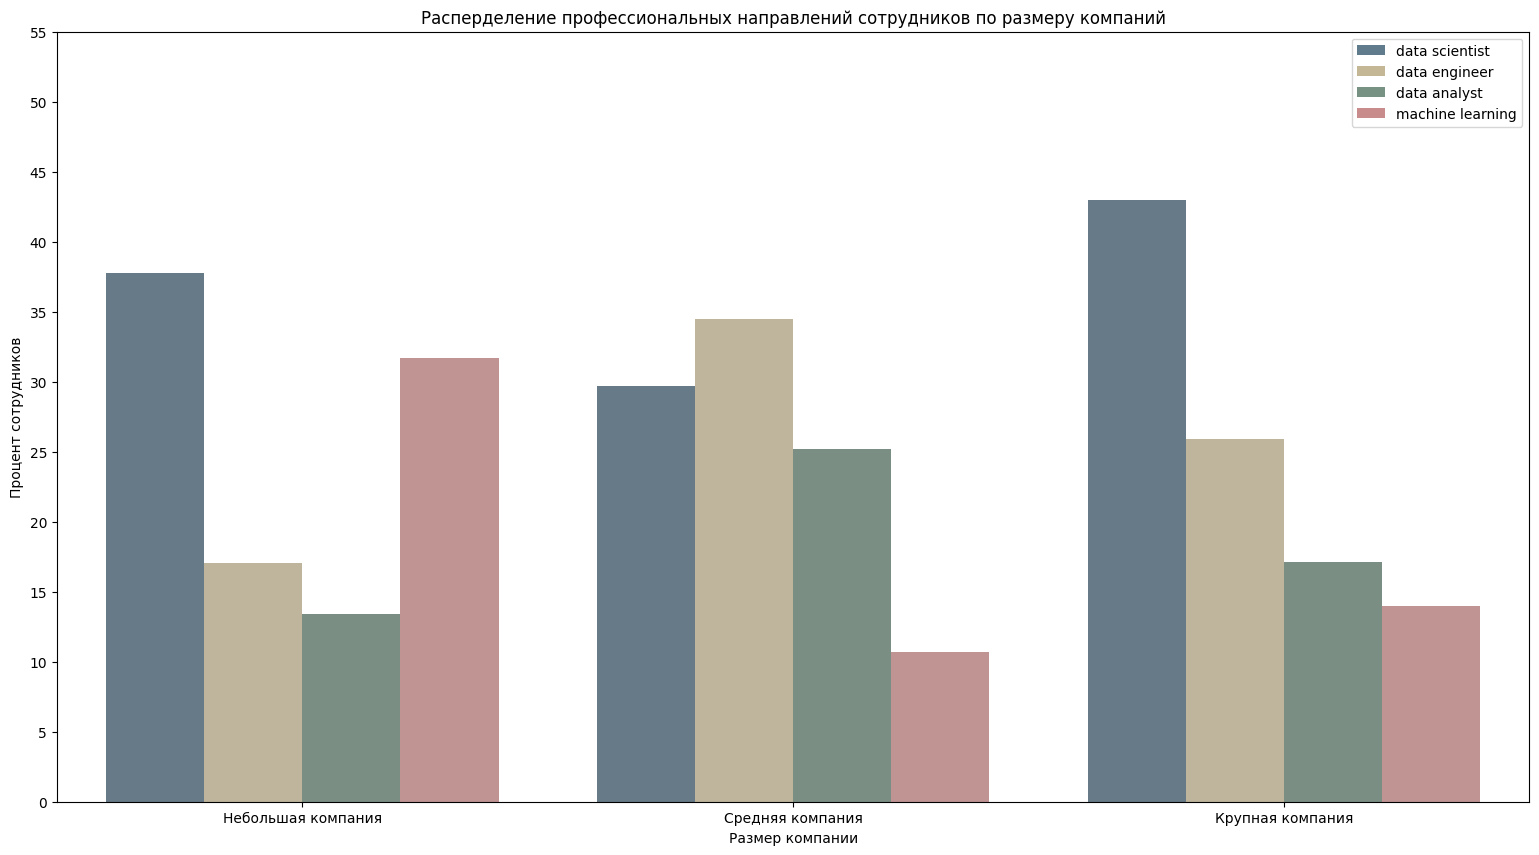

In [155]:
share_domains = data.groupby('company_size', sort=False, as_index=False)['domain'].value_counts(normalize=True)
share_domains['proportion'] = round(share_domains['proportion']*100, 2)
# figure
fig = plt.figure(figsize=(19,10))
# barplot
barplot = sns.barplot(
    data=share_domains,
    x='company_size',
    y='proportion',
    hue='domain',
    order=['S', 'M', 'L'],
    hue_order=['data scientist', 'data engineer', 'data analyst', 'machine learning'],
    palette=['#607C8C','#C4B796',  '#779182', '#C98C8C'],
    errorbar=None
)
# set labels name
barplot.set_title('Расперделение профессиональных направлений сотрудников по размеру компаний')
barplot.set_xlabel('Размер компании')
barplot.set_ylabel('Процент сотрудников')
# set ticks
barplot.set_xticks(['S', 'M', 'L'])
barplot.set_xticklabels(['Небольшая компания', 'Средняя компания', 'Крупная компания'])
y_ticks = range(0, int(share_levels['proportion'].max()) + 5, 5)
barplot.set_yticks(y_ticks)
# set legend
legend_handles = [Patch(facecolor='#607C8C', label='data scientist'), 
                  Patch(facecolor='#C4B796', label='data engineer'),
                  Patch(facecolor='#779182', label='data analyst'),
                  Patch(facecolor='#C98C8C', label='machine learning'),]
barplot.legend(handles=legend_handles, title=None);

### 2.8 Распределение годовой зарплаты по профессиональным направлениям

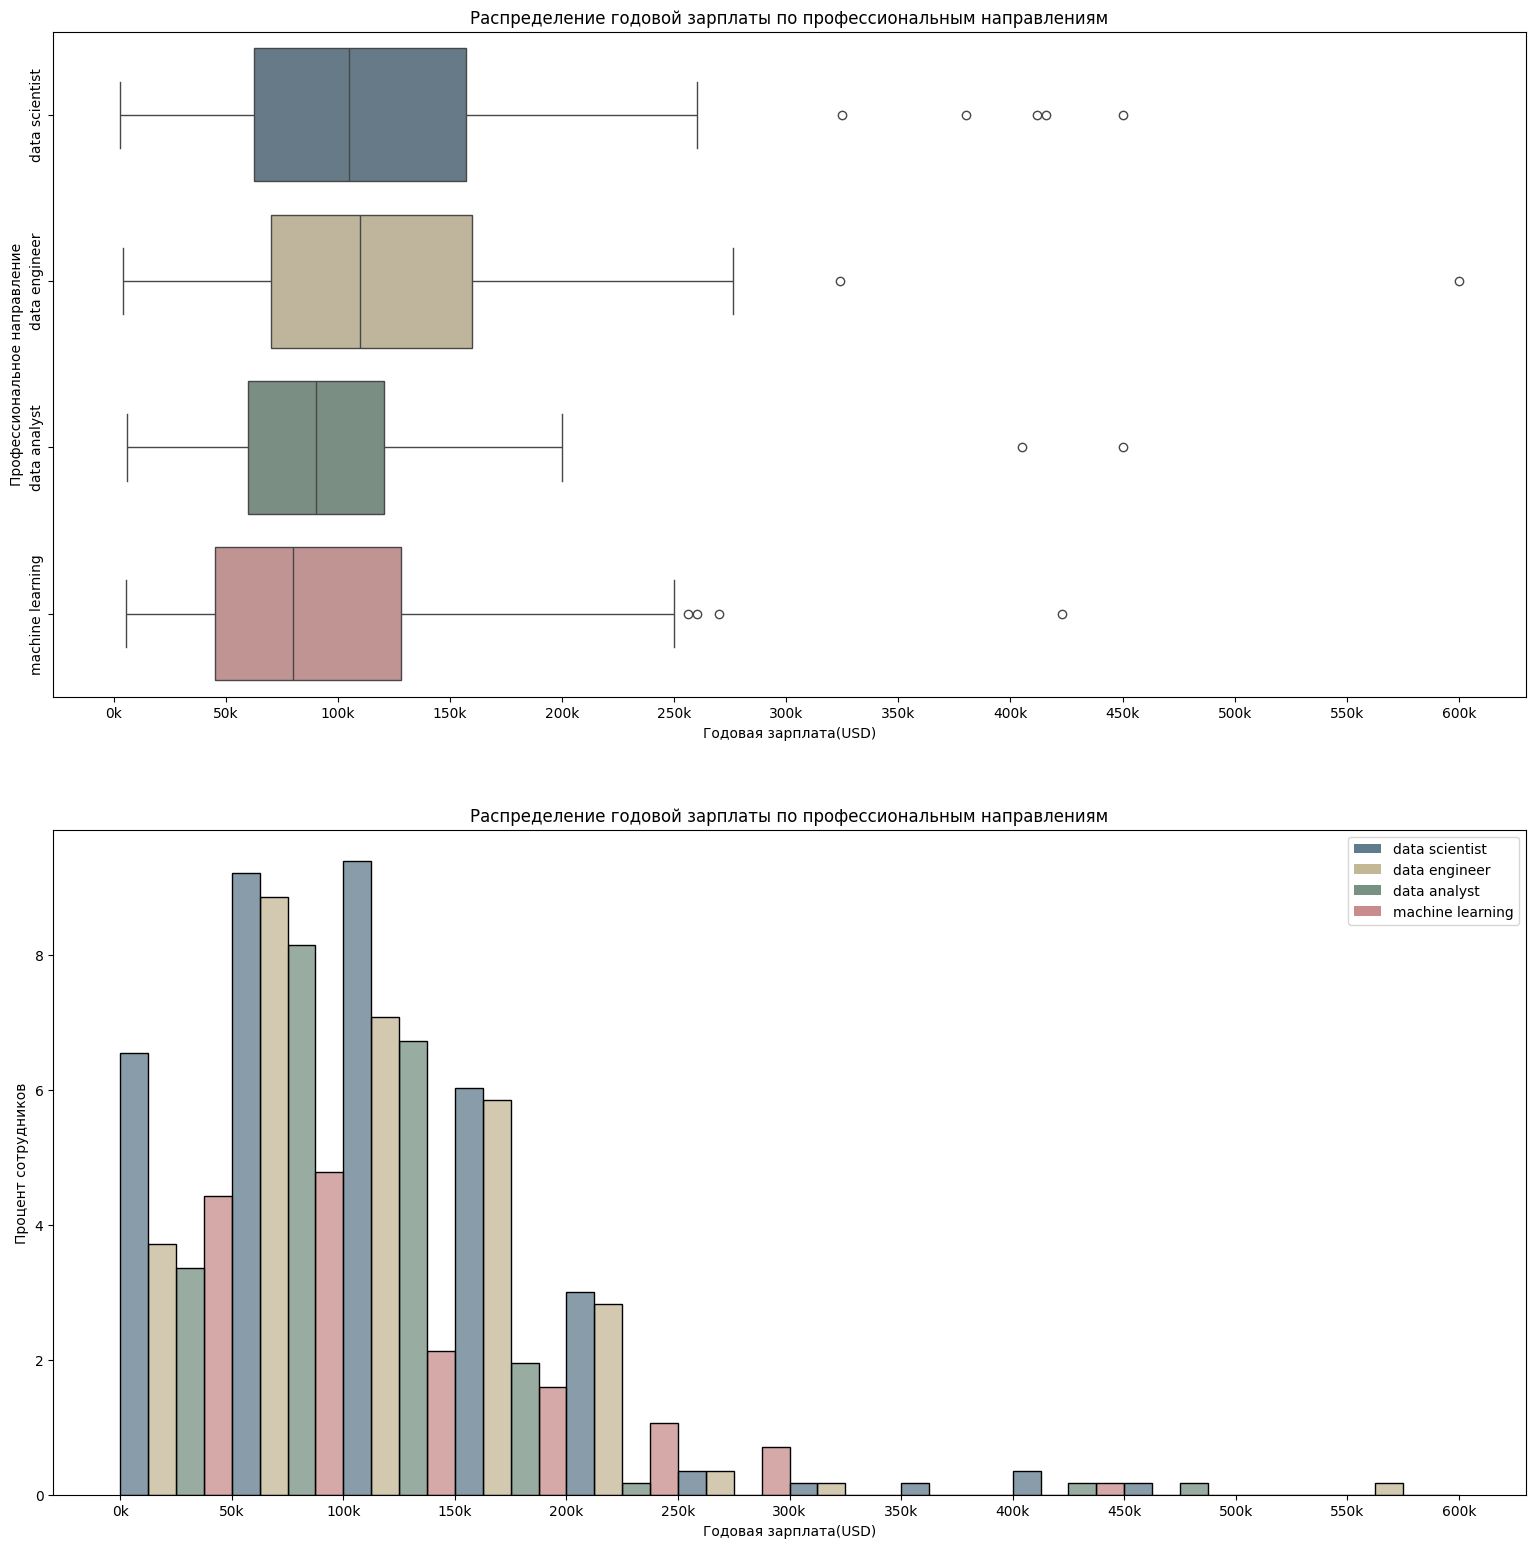

In [156]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(19,19))
# boxplot
boxplot = sns.boxplot(
    data=data,
    x='salary_in_usd',
    y='domain',
    hue='domain',
    order=['data scientist', 'data engineer', 'data analyst', 'machine learning'],
    hue_order=['data scientist', 'data engineer', 'data analyst', 'machine learning'],
    palette=['#607C8C','#C4B796',  '#779182', '#C98C8C'],
    ax=axes[0]
)
# set labels name
boxplot.set_title('Распределение годовой зарплаты по профессиональным направлениям')
boxplot.set_xlabel('Годовая зарплата(USD)')
boxplot.set_ylabel('Профессиональное направление')
# set ticks
x_ticks = range(0, data['salary_in_usd'].max() + 5*10**4, 5*10**4)
boxplot.set_xticks(x_ticks)
boxplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
boxplot.set_yticks(['data scientist', 'data engineer', 'data analyst', 'machine learning'])
boxplot.set_yticklabels(['data scientist', 'data engineer', 'data analyst', 'machine learning'], rotation=90, va='center')


# histplot
histplot = sns.histplot(
    data=data,
    x='salary_in_usd',
    hue='domain',
    hue_order=['data scientist', 'data engineer', 'data analyst', 'machine learning'],
    stat='percent',
    bins=x_ticks,
    multiple='dodge',
    palette=['#607C8C','#C4B796',  '#779182', '#C98C8C'],
    ax=axes[1]
)
# set labels name
histplot.set_title('Распределение годовой зарплаты по профессиональным направлениям')
histplot.set_xlabel('Годовая зарплата(USD)')
histplot.set_ylabel('Процент сотрудников')
# set ticks
histplot.set_xticks(x_ticks)
histplot.set_xticklabels([f'{(int(val/1000))}k' for val in x_ticks])
# set legend
legend_handles = [Patch(facecolor='#607C8C', label='data scientist'), 
                  Patch(facecolor='#C4B796', label='data engineer'),
                  Patch(facecolor='#779182', label='data analyst'),
                  Patch(facecolor='#C98C8C', label='machine learning'),]
histplot.legend(handles=legend_handles, title=None);

In [157]:
order = ['data scientist', 'data engineer', 'data analyst', 'machine learning']
data.groupby('domain')['salary_in_usd'].describe().round(2).loc[order]


,count,mean,std,min,25%,50%,75%,max
domain,,,,,,,,
data scientist,200.0,116900.42,75009.27,2859.0,62353.50,104796.0,157300.0,450000.0
data engineer,164.0,118957.76,71643.45,4000.0,69935.25,110000.0,160000.0,600000.0
data analyst,117.0,95612.84,61392.94,6072.0,60000.00,90320.0,120600.0,450000.0
machine learning,84.0,100226.04,77490.22,5409.0,45046.25,80019.5,128250.0,423000.0


Вывод:  
Распределение данных отличается от нормального. Данные распределены похожим образом для всех профессиональных направлений. Различия в средней и медианной годовой зарплате по направлениям существуют. Выбросы присутствуют в каждой из категорий.

## **3. Статистический анализ данных**

In [158]:
# задаём уровень значимости
alpha = 0.05 
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))
      

### 3.1 Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?

In [159]:
# filter data
ds_only = data[data['domain'] == 'data scientist']
# test normal distribution
shapiro = stats.shapiro(ds_only['salary_in_usd'])
print(round(shapiro[1], 3))
# data distribution is not normal

0.0


Тест Спирмена для определения связи двух независмых переменных.  


$H_0$ - Для зарплат Data Scientist нет положительной связи по годам (или связь отрицательная).
$$ H_0 : p <= 0$$
$H_1$ -  Для зарплат Data Scientist есть положительная связь по годам.
$$ H_1 : p > 0$$

In [160]:
spearman_test_0 = stats.spearmanr(a=ds_only['work_year'], b=ds_only['salary_in_usd'], alternative='greater')
print('Коэффициент корреляции Спирмена -', round(spearman_test_0[0], 3))
print('p-value -', spearman_test_0[1])

Коэффициент корреляции Спирмена - 0.311
p-value - 3.667970804728372e-06


Вывод:  
При условии что $H_0$ истина, шанс наблюдать такие или более экстримальные значения крайне мал. $H_0$ отвергается. Для зарплат Data Scientist есть положительная связь по годам, сила связи слабая. Это говорит о том, что не сам год влияет на зарплату специалиста, а другие факторы. Однако утверждать что из года в год зарплата специалистов направления Data Scientist растет корректно.


### 3.2 Влияет ли профессиональный уровень на зарплату?

In [161]:
mapping = {
    'col':'experience_level',
    'mapping':{'EN':1, 'MI':2, 'SE':3, 'EX':4}
}
# encoding
ordinal_encoder = ce.OrdinalEncoder(mapping)
level_encoded = ordinal_encoder.fit_transform(data['experience_level'])
level_encoded = level_encoded.rename(columns={'experience_level':'experience_num'})
data = pd.concat([data, level_encoded], axis=1)
# test normal distribution
shapiro = stats.shapiro(data['salary_in_usd'])
print(round(shapiro[1], 3))
# data distribution is not normal

0.0


Тест Спирмена для определения связи двух независмых переменных.  


$H_0$ - Профессиональный уровень специалиста не влияет на зарплату или влияет отрицательно.
$$ H_0 : p <= 0$$
$H_1$ -  Профессиональный уровень специалиста положительно влияет на зарплату.
$$ H_1 : p > 0$$

In [162]:
spearman_test_1 = stats.spearmanr(a=data['experience_num'], b=data['salary_in_usd'], alternative='greater')
print('Коэффициент корреляции Спирмена -', round(spearman_test_1[0], 3))
print('p-value -', round(spearman_test_1[1], 3))

Коэффициент корреляции Спирмена - 0.137
p-value - 0.001


Вывод:  
При условии истинности нулевой гипотезы $H_0$ вероятность наблюдать такие или более экстремальные данные крайне мала, поэтому $H_0$ отвергается. Профессиональный уровень специалиста положительно влияет на годовую зарплату. Сила связи по Спирмену слабая, это указывает что профессиональный уровень не единственый фактор, влияющий на зарплату.

### 3.3 Влияет ли объем удаленной работы на годовую зарплату? 

In [163]:
mapping = {
    'col':'experience_level',
    'mapping':{'0':1, '50':2, '100':3}
}
# encoding
ordinal_encoder = ce.OrdinalEncoder(mapping)
level_encoded = ordinal_encoder.fit_transform(data['remote_ratio'])
level_encoded = level_encoded.rename(columns={'remote_ratio':'remote_num'})
data = pd.concat([data, level_encoded], axis=1)
# test normal distribution
shapiro = stats.shapiro(data['salary_in_usd'])
print(round(shapiro[1], 3))
# data distribution is not normal

0.0


Тест Спирмена для определения связи двух независмых переменных.  


$H_0$ - Объем удаленной работы специалиста не влияет на зарплату или влияет отрицательно.
$$ H_0 : p <= 0$$
$H_1$ -  Объем удаленной работы специалиста положительно влияет на зарплату.
$$ H_1 : p > 0$$

In [164]:
spearman_test_2 = stats.spearmanr(a=data['remote_num'], b=data['salary_in_usd'], alternative='greater')
print('Коэффициент корреляции Спирмена -', round(spearman_test_2[0], 3))
print('p-value -', round(spearman_test_2[1], 3))

Коэффициент корреляции Спирмена - 0.164
p-value - 0.0


Вывод:  
При том что $H_0$ истинна, шанс наблюдать такие или более экстримальные значения, слоставляет около нуля. Нуливая гипотеза отвергается. Прнимаем $H_1$. Утверждать, что объем удаленной работы влияет на годовую зарплату сотрудника корректно. Сила связи слабая. 

### 3.4 Различается ли годовая заработная плата местных специалистов и не местных?

**Примечание**: *Местный специалист*/ *Не местный специалсит*, термины существуют ,исключительно, в контексте совпадает ли страна проживания специалиста со страной регистрации компании. 

In [ ]:
group_0 = data[data['is_same_country'] == 'True']['salary_in_usd']
group_1 = data[data['is_same_country'] == 'False']['salary_in_usd']
shapiro_0 = stats.shapiro(group_0)
print(round(shapiro[1], 3))
shapiro_1 = stats.shapiro(group_1)
print(round(shapiro[1], 3))
# data distribution is not normal

0.0
0.0


Пермутационный тест с медианой. Суть теста: если группы сформированы из одной совокупности то перестановка наблюдений между ними случайным образом, не должна давать стистически значимой разницы в выбранной метрике. Если же разница статистически значима, то группы сформированны из разных совокупностей. 


$H_0$ - Местные специалисты $μ_0$ получают такую же или меньше годовую зарплату, чем специалисты не местные $μ_1$.
$$ H_0 : μ_0 <= μ_1$$
$H_1$ -  Местные специалисты $μ_0$ получают годовую зарплату выше, чем не местные $μ_1$.
$$ H_1 : μ_0 > μ_1$$

In [166]:
permutation_test = stats.permutation_test(data=(group_0, group_1),
                                          statistic=lambda x, y: np.median(x) - np.median(y),
                                          alternative='greater',
                                          n_resamples=10000,
                                          random_state=42)
round(permutation_test.pvalue, 5)

np.float64(0.0002)

Вывод:  
При условии что $H_0$ верна, результаты теста демонстрируеют, что вероятность наблюдать такие или более экстримальные значения близка к нулую. $H_0$ отвергается, принимаем $H_1$. Годовая зарплата местных специалистов выше, чем зарплата не местных специалистов. 

### 3.5 Влияет ли соотношение специалистов по профессиональному уровню внутри компании на показатели годовой зарплаты специалистов компаниий в разрезе размера компании?

**Примечание**: Графики показали, что годовая зарплата в малеьникх копаниях ниже, чем в других. Так же графики подтвердили, что в маленьких компаниях доля начинающих специалистов выше, чем в других компаниях. Имеет ли статистическую значимость разница в соотношении опыта специалистов. 

In [167]:
cross_table = pd.crosstab(data['company_size'], data['experience_level'])
display(cross_table)

experience_level,EN,EX,MI,SE
company_size,,,,
L,29,11,84,69
M,30,12,96,152
S,29,3,28,22


Выборка данных имеет малое  количество наблюдений в одной из ячеек (менее 5). Применяем тест точный критерий Фишера для таблиц RxC.

$H_0$ - Разница распределении специалистов по опыту внутри компании не влияет на размер годовой зарплаты в разрезе размера компании.
$$ H_0 : p = 0 $$

$H_1$ - Разница распределении специалистов по опыту внутри компании влияет на размер годовой зарплаты в разрезе размера компании.
$$ H_1 : p > 0 $$



In [168]:
cross_table.values
fisher_test = fisher.exact(cross_table.values)
print('Fisher test p-value', fisher_test)

Fisher test p-value 4.910262014519175e-07


Вывод:  
Если разница в соотношении специалистов внутри компании не существенна, то вероятность наблюдать такие или более экстримальные наблюдения близка к нулю. $H_0$ отвергается. Можно утверждать, что разница в годовх зарплатах в разрезе размера компаний, обусловлена соотношением специалистов работающих в них. Принимаем $H_1$.

### 3.6 Есть ли разница в годовых зарплатах по профессиональному направлению? 

In [ ]:
ds_salary = data[data['domain'] == 'data scientist']['salary_in_usd']
de_salary = data[data['domain'] == 'data engineer']['salary_in_usd']
da_salary = data[data['domain'] == 'data analyst']['salary_in_usd']
ml_salary = data[data['domain'] == 'machine learning']['salary_in_usd']

Пермутационный тест с медианой. Суть теста: если группы сформированы из одной совокупности то перестановка наблюдений между ними случайным образом, не должна давать стистически значимой разницы в выбранной метрике. Если же разница статистически значима, то группы сформированны из разных совокупностей.

$H_0$ - Годовая зарплата data scientist $μ_0$ меньше или равна зарплате $μ_1$ data engineer.
$$ H_0 : μ_0 <= μ_1$$
$H_1$ - Годовая зарплата data scientist $μ_0$ больше зарплаты $μ_1$ data engineer.
$$ H_1 : μ_0 > μ_1$$

In [174]:
permutation_test_ds_de = stats.permutation_test(data=(ds_salary, de_salary),
                                          statistic=lambda x, y: np.median(x) - np.median(y),
                                          alternative='greater',
                                          n_resamples=10000,
                                          random_state=42)
round(permutation_test_ds_de.pvalue, 5)

np.float64(0.70323)

**Принимаем $H_0$**

$H_0$ - Годовая зарплата data scientist $μ_0$ равна зарплате $μ_1$ data engineer.
$$ H_0 : μ_0 == μ_1$$
$H_1$ - Годовая зарплата data scientist $μ_0$ не равна зарплате $μ_1$ data engineer.
$$ H_1 : μ_0 \neq μ_1$$

In [181]:
permutation_test_ds_de = stats.permutation_test(data=(ds_salary, de_salary),
                                          statistic=lambda x, y: np.median(x) - np.median(y),
                                          alternative='two-sided',
                                          n_resamples=10000,
                                          random_state=42)
round(permutation_test_ds_de.pvalue, 5)

np.float64(0.60034)

**Принимаем $H_0$**

$H_0$ - Годовая зарплата data scientist $μ_0$ меньше или равна зарплате $μ_1$ data analyst.
$$ H_0 : μ_0 <= μ_1$$
$H_1$ - Годовая зарплата data scientist $μ_0$ больше зарплаты $μ_1$ data analyst.
$$ H_1 : μ_0 > μ_1$$

In [175]:
permutation_test_ds_da = stats.permutation_test(data=(ds_salary, da_salary),
                                          statistic=lambda x, y: np.median(x) - np.median(y),
                                          alternative='greater',
                                          n_resamples=10000,
                                          random_state=42)
round(permutation_test_ds_da.pvalue, 5)

np.float64(0.0355)

**Принимаем $H_1$**

$H_0$ - Годовая зарплата data scientist $μ_0$ меньше или равна зарплате $μ_1$ machine learning.
$$ H_0 : μ_0 <= μ_1$$
$H_1$ - Годовая зарплата data scientist $μ_0$ больше зарплаты $μ_1$ machine learning.
$$ H_1 : μ_0 > μ_1$$


In [176]:
permutation_test_ds_ml = stats.permutation_test(data=(ds_salary, ml_salary),
                                          statistic=lambda x, y: np.median(x) - np.median(y),
                                          alternative='greater',
                                          n_resamples=10000,
                                          random_state=42)
round(permutation_test_ds_ml.pvalue, 5)

np.float64(0.0088)

**Принимаем $H_1$**


*Примечание. Цель данного практического задания не в получении максимально достоверных результатов или сложных тестов, а в понимании структуры данных, извлечении и обработке признаков, проведении статистических тестов, интерпретации их результатов и построении графиков. Это можно считать первой итерацией проекта.*
### Вывод:  
Далее необходимо провести тест, учитывающий зависимые p‑значения, поскольку в исследовании использовались парные сравнения внутри одной выборки и результаты взаимозависимы. Можно также применить альтернативный подход, учитывающий зависимость наблюдений. Сейчас же можно сделать предварительные выводы, основанные на визуальном и статистическом анализе данных. Зарплаты Data Scientist и Data Engineer сопоставимы; Data Scientist получают выше, чем специалисты Data Analyst и Machine Learning Engineer. Можно предположить, что Data Engineer также получают выше, чем Data Analyst и Machine Learning Engineer.  
**Что влияет на зарплату специалиста Data Scientist и других ролей?**    
Данные показывают связь зарплаты с профессиональным уровнем специалиста, долей удалённой работы, совпадением города проживания и города компании, а также с профессиональным направлением. Следует отметить, что статистические тесты выявляют зависимость между переменными, но не объясняют причинно-следственные связи. Маловероятно, что объём удалённой работы или совпадение города напрямую определяют зарплату, скорее это отражение влияния других факторов, не включённых в набор данных. Здравый смысл подсказывает, что реальные драйверы зарплаты: опыт, технические навыки, уровень самостоятельности, софт‑скиллы и другие характеристики, которые в данных не представлены. В имеющемся наборе два признака показали статистическую значимость: профессиональный уровень и профессиональное направление это логично и обоснованно.  

**Что планируется сделать в будущем?**
* Оформить проект надлежащим образом: описать цели и задачи, сформулировать ключевые вопросы.
* Провести дополнительные тесты и ответить на нерешённые вопросы. Например: существует ли различие в распределении ролей Data Scientist и Data Engineer в компаниях разного размера?
* Выпустить вторую итерацию проекта с расширённым набором признаков и более подходящими статистическими методами, исчерпывающими выводами и тд.